In [242]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### 1. Missing Value Profiling and Handling Strategy

In [243]:
df = pd.read_csv(filepath_or_buffer="netflix_titles.csv")

In [244]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [245]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [246]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

I do not think there is a need to drop those rows where there are some `NaN` values. Better is to fill them with boilerplate `unrecorder` value - we already are short of data, dropping them will cause distorted analysis.

In [247]:
df = df.fillna(value="unrecorded")

In [248]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8807 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8807 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


### 2. Duration Parsing and Standardization

In [249]:
df["type"].unique()

<ArrowStringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [250]:
df["duration_minutes"] = (
    df["duration"]
    .where(df["duration"].str.contains("min", na=False))
    .str.split()
    .str[0]
    .astype("float")
)

df["duration_seasons"] = (
    df["duration"]
    .where(df["duration"].str.lower().str.contains("season", na=False))
    .str.split()
    .str[0]
    .astype("float")
)

In [251]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unrecorded,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,NaN
1,s2,TV Show,Blood & Water,unrecorded,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unrecorded,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,unrecorded,unrecorded,unrecorded,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN,1.0
4,s5,TV Show,Kota Factory,unrecorded,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN,2.0


### 3. Temporal Format Standardization

In [252]:
df["date_added"] = pd.to_datetime(
    df["date_added"].str.strip(),
    format="%B %d, %Y",
    errors="coerce",
)

In [253]:
df["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

In [254]:
(df["date_added"].dtype)

dtype('<M8[us]')

In [255]:
df["date_added"].isnull().sum()

np.int64(10)

In [256]:
df["date_added_year"] = df["date_added"].dt.year
df["date_added_month"] = df["date_added"].dt.month
df["date_added_day"] = df["date_added"].dt.day

In [257]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8807 non-null   str           
 1   type              8807 non-null   str           
 2   title             8807 non-null   str           
 3   director          8807 non-null   str           
 4   cast              8807 non-null   str           
 5   country           8807 non-null   str           
 6   date_added        8797 non-null   datetime64[us]
 7   release_year      8807 non-null   int64         
 8   rating            8807 non-null   str           
 9   duration          8807 non-null   str           
 10  listed_in         8807 non-null   str           
 11  description       8807 non-null   str           
 12  duration_minutes  6128 non-null   float64       
 13  duration_seasons  2676 non-null   float64       
 14  date_added_year   8797 non-null   f

### 4. Format Strategy Over Time

In [258]:
year_type_titles = (
    df.groupby(by=["release_year", "type"])
    .agg(titles=("show_id", "count"))
    .sort_values(by="release_year")
    .reset_index()
)

In [259]:
year_type_titles.head()

,release_year,type,titles
0,1925,TV Show,1
1,1942,Movie,2
2,1943,Movie,3
3,1944,Movie,3
4,1945,Movie,3


In [260]:
pivot_data = (
    year_type_titles.pivot(
        index="release_year",
        columns="type",
        values="titles",
    )
    .fillna(0)
    .sort_index()
)


In [261]:
pivot_data.head()

type,Movie,TV Show
release_year,,
1925,0.0,1.0
1942,2.0,0.0
1943,3.0,0.0
1944,3.0,0.0
1945,3.0,1.0


In [262]:
# if "Movie" not in pivot_data.columns:
# checks if the column named "Movie" exists in the pivoted DataFrame.
# pivot_data["Movie"] = 0 initializes a new column named "Movie"
# populated entirely with zeros if it was missing.
# The same logic is applied to "TV Show".

if "Movie" not in pivot_data.columns:
    pivot_data["Movie"] = 0
if "TV Show" not in pivot_data.columns:
    pivot_data["TV Show"] = 0

In [263]:
pivot_data["Total"] = pivot_data["Movie"] + pivot_data["TV Show"]
pivot_data["Movie_Pct"] = (
    pivot_data["Movie"] / pivot_data["Total"].replace(0, 1)
) * 100
pivot_data["TV_Pct"] = (
    pivot_data["TV Show"] / pivot_data["Total"].replace(0, 1)
) * 100

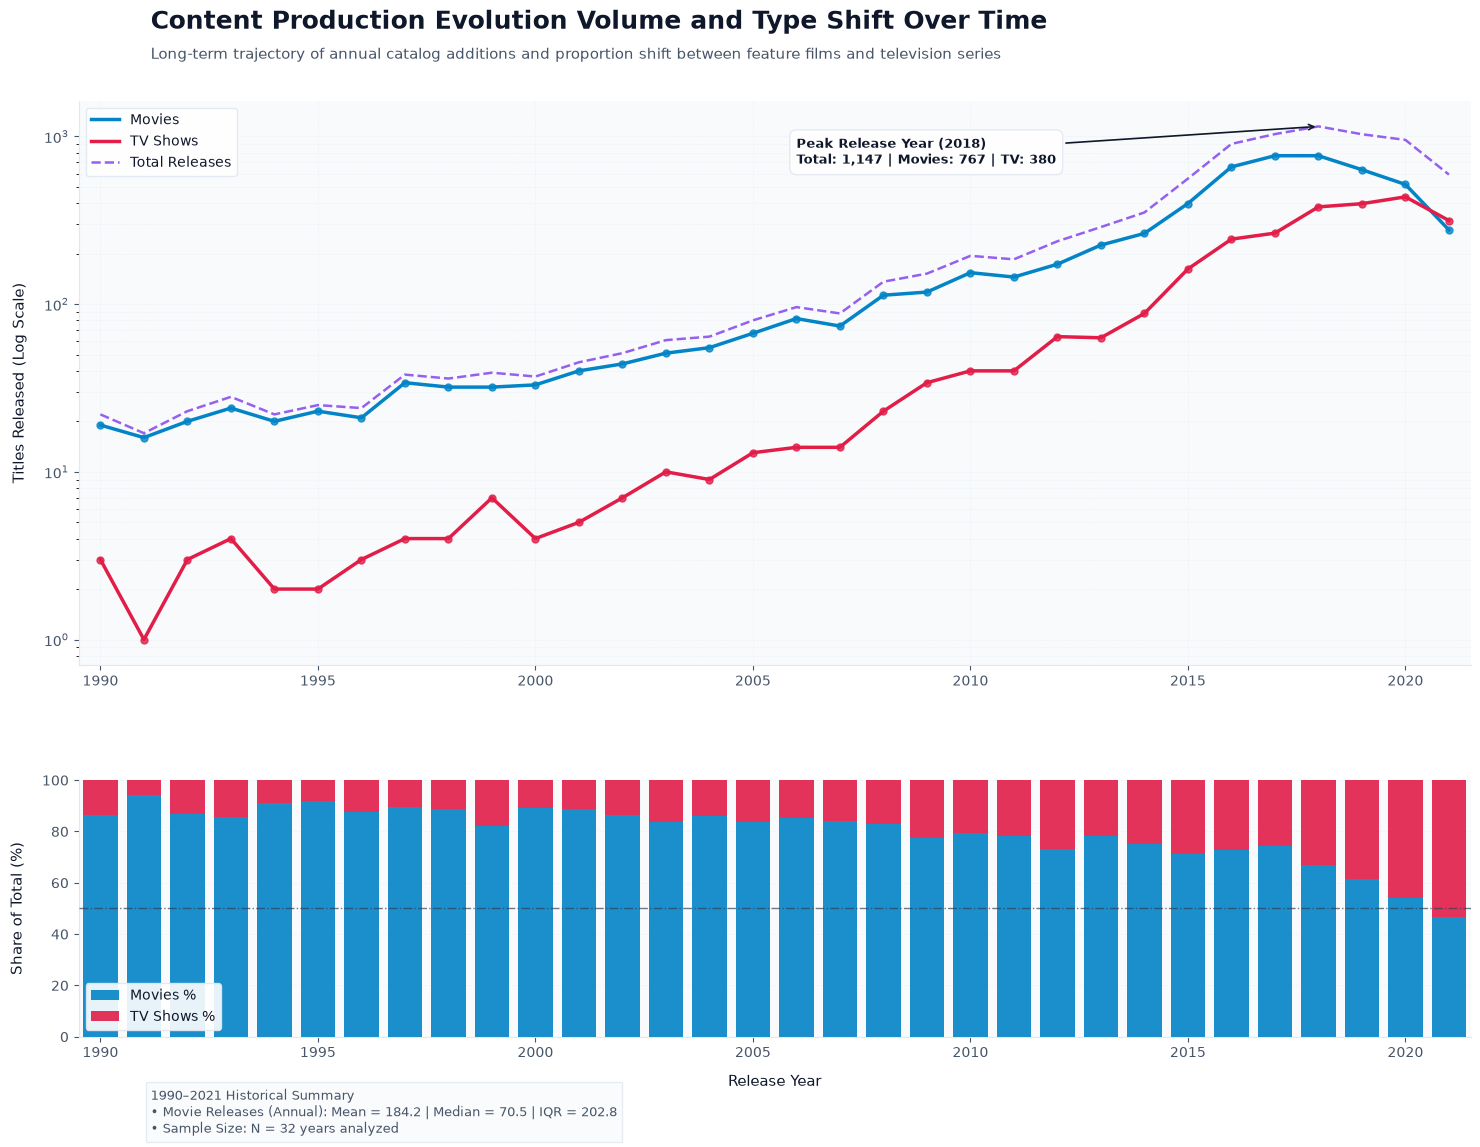

In [264]:
all_years = np.arange(pivot_data.index.min(), pivot_data.index.max() + 1)
pivot_data = pivot_data.reindex(all_years, fill_value=0)

recent_data = pivot_data.loc[pivot_data.index >= 1990]

BG_COLOR = "#FFFFFF"
PANEL_BG = "#F8FAFC"
TEXT_COLOR = "#0F172A"
MUTED_TEXT = "#475569"
MOVIE_COLOR = "#0284C7"
TV_COLOR = "#E11D48"
GRID_COLOR = "#E2E8F0"

title_text = "Content Production Evolution Volume and Type Shift Over Time"

fig = plt.figure(figsize=(16, 12), facecolor=BG_COLOR)
gs = fig.add_gridspec(2, 1, height_ratios=[2.2, 1], hspace=0.28)

ax0 = fig.add_subplot(gs[0], facecolor=PANEL_BG)
ax1 = fig.add_subplot(gs[1], facecolor=PANEL_BG)

years = recent_data.index.values
movies = recent_data["Movie"].values
tv_shows = recent_data["TV Show"].values
totals = recent_data["Total"].values

ax0.plot(
    years, movies, color=MOVIE_COLOR, linewidth=2.5, label="Movies", zorder=4
)
ax0.scatter(years, movies, color=MOVIE_COLOR, s=25, alpha=0.8, zorder=5)

ax0.plot(
    years, tv_shows, color=TV_COLOR, linewidth=2.5, label="TV Shows", zorder=4
)
ax0.scatter(years, tv_shows, color=TV_COLOR, s=25, alpha=0.8, zorder=5)

ax0.plot(
    years,
    totals,
    color="#7C3AED",
    linewidth=1.8,
    linestyle="--",
    label="Total Releases",
    alpha=0.8,
    zorder=3,
)

ax0.set_yscale("log")
ax0.grid(
    True,
    which="both",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)
ax0.set_ylabel(
    "Titles Released (Log Scale)", color=TEXT_COLOR, fontsize=11, labelpad=12
)

max_year = recent_data["Total"].idxmax()
max_total = recent_data.loc[max_year, "Total"]
max_movie = recent_data.loc[max_year, "Movie"]
max_tv = recent_data.loc[max_year, "TV Show"]

ax0.annotate(
    f"Peak Release Year ({max_year})\nTotal: {int(max_total):,} | Movies: {int(max_movie):,} | TV: {int(max_tv):,}",
    xy=(max_year, max_total),
    xytext=(max_year - 12, max_total * 0.6),
    arrowprops={"arrowstyle": "->", "color": TEXT_COLOR, "lw": 1.2},
    color=TEXT_COLOR,
    fontsize=9.5,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": BG_COLOR,
        "edgecolor": GRID_COLOR,
        "alpha": 0.9,
    },
)

movie_pcts = recent_data["Movie_Pct"].values
tv_pcts = recent_data["TV_Pct"].values

ax1.bar(
    years,
    movie_pcts,
    color=MOVIE_COLOR,
    label="Movies %",
    width=0.8,
    alpha=0.9,
    zorder=3,
)
ax1.bar(
    years,
    tv_pcts,
    bottom=movie_pcts,
    color=TV_COLOR,
    label="TV Shows %",
    width=0.8,
    alpha=0.9,
    zorder=3,
)

ax1.axhline(
    50, color="#334155", linestyle="-.", linewidth=1, alpha=0.7, zorder=4
)
ax1.set_ylabel("Share of Total (%)", color=TEXT_COLOR, fontsize=11, labelpad=12)
ax1.set_ylim(0, 100)
ax1.set_xlabel("Release Year", color=TEXT_COLOR, fontsize=11, labelpad=10)
ax1.grid(
    True,
    which="major",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)

for ax in [ax0, ax1]:
    ax.tick_params(colors=MUTED_TEXT, labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID_COLOR)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.set_xlim(years.min() - 0.5, years.max() + 0.5)

ax0.set_xticks(np.arange(1990, years.max() + 1, 5))
ax1.set_xticks(np.arange(1990, years.max() + 1, 5))

mean_movies = recent_data["Movie"].mean()
median_movies = recent_data["Movie"].median()
iqr_movies = recent_data["Movie"].quantile(0.75) - recent_data[
    "Movie"
].quantile(0.25)

stats_str = (
    f"1990–{years.max()} Historical Summary\n"
    f"• Movie Releases (Annual): Mean = {mean_movies:.1f} | Median = {median_movies:.1f} | IQR = {iqr_movies:.1f}\n"
    f"• Sample Size: N = {len(recent_data)} years analyzed"
)

fig.text(
    0.125, 0.94, title_text, color=TEXT_COLOR, fontsize=18, fontweight="bold"
)
fig.text(
    0.125,
    0.915,
    "Long-term trajectory of annual catalog additions and proportion shift between feature films and television series",
    color=MUTED_TEXT,
    fontsize=11,
)

fig.text(
    0.125,
    0.02,
    stats_str,
    color=MUTED_TEXT,
    fontsize=9,
    bbox={
        "boxstyle": "square,pad=0.4",
        "facecolor": PANEL_BG,
        "edgecolor": GRID_COLOR,
        "alpha": 0.8,
    },
)

handles0, labels0 = ax0.get_legend_handles_labels()
ax0.legend(
    handles0,
    labels0,
    loc="upper left",
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=10,
    framealpha=0.9,
)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(
    handles1,
    labels1,
    loc="lower left",
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=10,
    framealpha=0.9,
)

plt.subplots_adjust(top=0.88, bottom=0.1, left=0.08, right=0.95)

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path,
    dpi=800,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

### 5. Multi-Valued Geographical Footprint

In [265]:
countries_titles: dict[str, float] = {}

for countries in df["country"]:
    if countries.startswith("unrecorded"):
        continue

    countries_list: list = countries.strip().split(",")
    if len(countries_list) == 1:
        countries_titles[countries_list[0]] = (
            countries_titles.get(countries_list[0], 0) + 1
        )
        continue

    for country in countries_list:
        countries_titles[country] = round(
            countries_titles.get(country, 0) + 1 / len(countries_list), 1
        )

countries_titles = sorted(
    countries_titles.items(), key=lambda item: item[1], reverse=True
)

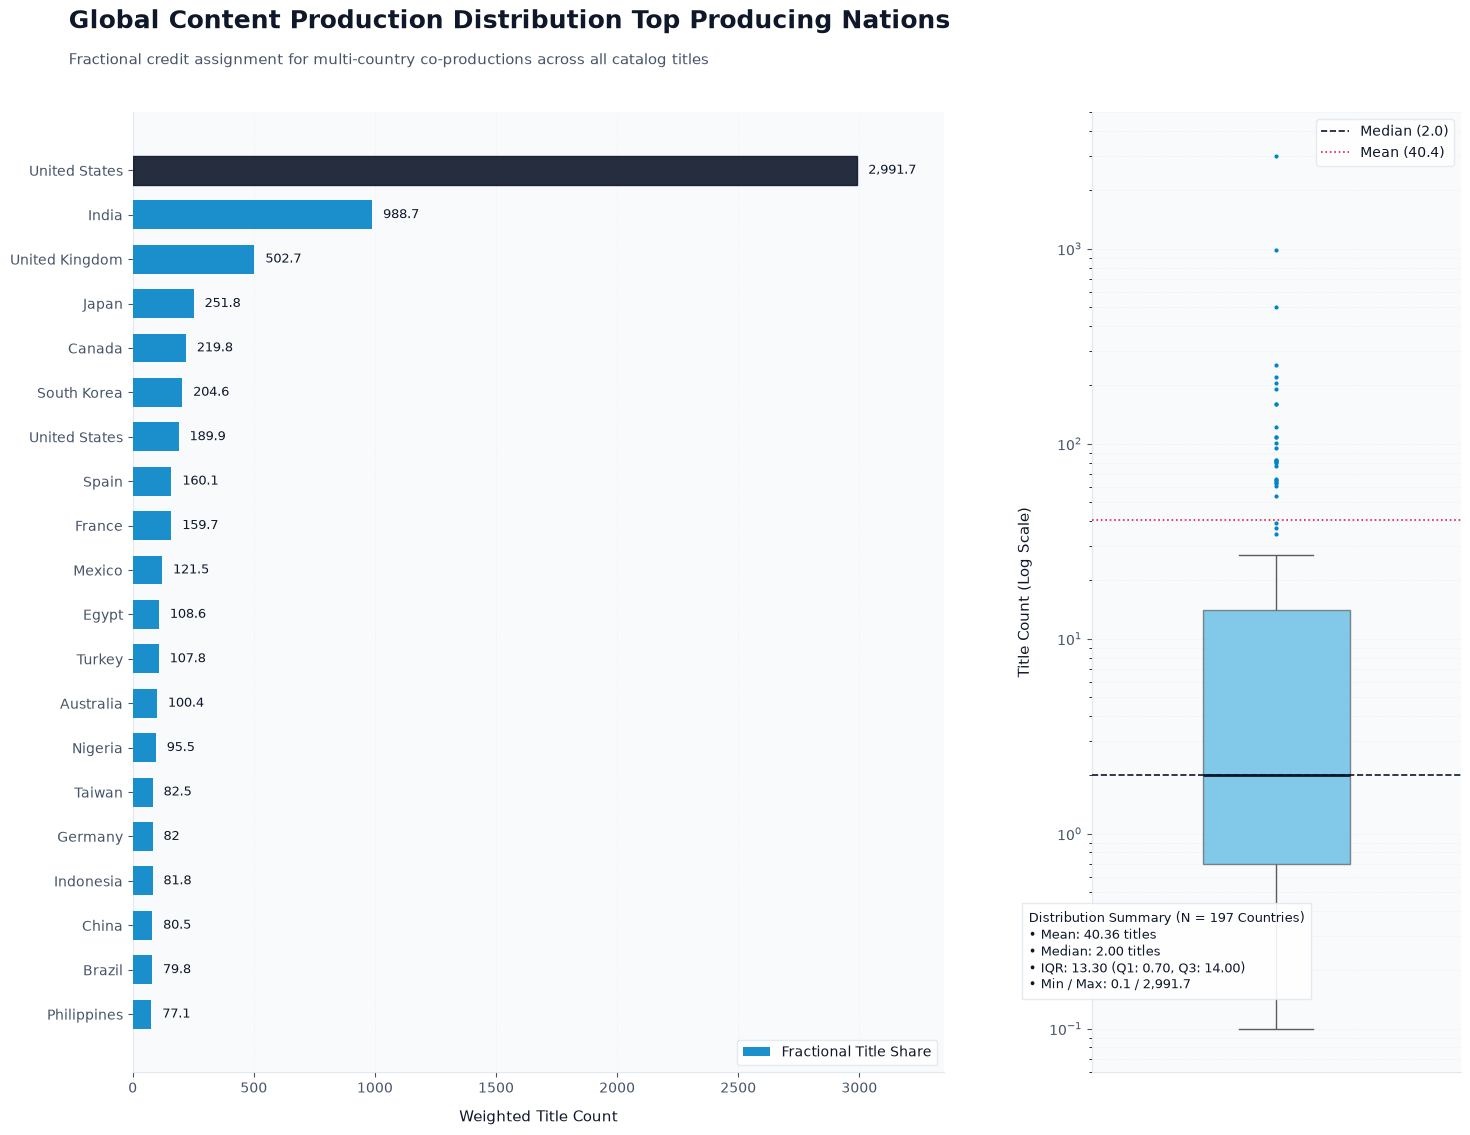

In [266]:
country_df = pd.DataFrame(countries_titles, columns=["Country", "Titles"])
top_20 = country_df.head(20).copy()
top_20 = top_20.iloc[::-1].reset_index(drop=True)

BG_COLOR = "#FFFFFF"
PANEL_BG = "#F8FAFC"
TEXT_COLOR = "#0F172A"
MUTED_TEXT = "#475569"
PRIMARY_COLOR = "#0284C7"
SECONDARY_COLOR = "#38BDF8"
ACCENT_COLOR = "#0F172A"
GRID_COLOR = "#E2E8F0"

title_text = "Global Content Production Distribution Top Producing Nations"

fig = plt.figure(figsize=(16, 12), facecolor=BG_COLOR)
gs = fig.add_gridspec(1, 2, width_ratios=[2.2, 1], wspace=0.25)

ax0 = fig.add_subplot(gs[0], facecolor=PANEL_BG)
ax1 = fig.add_subplot(gs[1], facecolor=PANEL_BG)

bars = ax0.barh(
    top_20["Country"],
    top_20["Titles"],
    color=PRIMARY_COLOR,
    height=0.65,
    alpha=0.9,
    zorder=3,
    label="Fractional Title Share",
)

bars[-1].set_color(ACCENT_COLOR)

max_val = top_20["Titles"].max()
for bar, value in zip(bars, top_20["Titles"]):
    ax0.text(
        value + (max_val * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.1f}" if value % 1 != 0 else f"{int(value):,}",
        va="center",
        ha="left",
        color=TEXT_COLOR,
        fontsize=9.5,
        fontweight="medium",
    )

ax0.set_xlabel(
    "Weighted Title Count", color=TEXT_COLOR, fontsize=11, labelpad=10
)
ax0.set_xlim(0, max_val * 1.12)
ax0.grid(
    True,
    which="major",
    axis="x",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)

all_values = country_df["Titles"].values
non_zero_values = all_values[all_values > 0]

sns.boxplot(
    y=non_zero_values,
    ax=ax1,
    color=SECONDARY_COLOR,
    width=0.4,
    fliersize=3,
    flierprops={"markerfacecolor": PRIMARY_COLOR, "markeredgecolor": "none"},
    medianprops={"color": ACCENT_COLOR, "linewidth": 2},
    boxprops={"alpha": 0.7},
    zorder=3,
)

ax1.set_yscale("log")
ax1.set_ylabel(
    "Title Count (Log Scale)", color=TEXT_COLOR, fontsize=11, labelpad=12
)
ax1.set_xticks([])
ax1.grid(
    True,
    which="both",
    axis="y",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)

mean_val = np.mean(non_zero_values)
median_val = np.median(non_zero_values)
q25 = np.percentile(non_zero_values, 25)
q75 = np.percentile(non_zero_values, 75)
iqr_val = q75 - q25

ax1.axhline(
    median_val,
    color=ACCENT_COLOR,
    linestyle="--",
    linewidth=1.2,
    label=f"Median ({median_val:.1f})",
    zorder=4,
)
ax1.axhline(
    mean_val,
    color="#E11D48",
    linestyle=":",
    linewidth=1.2,
    label=f"Mean ({mean_val:.1f})",
    zorder=4,
)

for ax in [ax0, ax1]:
    ax.tick_params(colors=MUTED_TEXT, labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID_COLOR)
    ax.spines["bottom"].set_color(GRID_COLOR)

stats_str = (
    f"Distribution Summary (N = {len(non_zero_values)} Countries)\n"
    f"• Mean: {mean_val:.2f} titles\n"
    f"• Median: {median_val:.2f} titles\n"
    f"• IQR: {iqr_val:.2f} (Q1: {q25:.2f}, Q3: {q75:.2f})\n"
    f"• Min / Max: {non_zero_values.min():.1f} / {non_zero_values.max():,.1f}"
)

fig.text(
    0.08,
    0.95,
    title_text,
    color=TEXT_COLOR,
    fontsize=18,
    fontweight="bold",
)
fig.text(
    0.08,
    0.92,
    "Fractional credit assignment for multi-country co-productions across all catalog titles",
    color=MUTED_TEXT,
    fontsize=11,
)

fig.text(
    0.68,
    0.15,
    stats_str,
    color=TEXT_COLOR,
    fontsize=9.5,
    bbox={
        "boxstyle": "square,pad=0.5",
        "facecolor": BG_COLOR,
        "edgecolor": GRID_COLOR,
        "alpha": 0.9,
    },
)

handles0, labels0 = ax0.get_legend_handles_labels()
ax0.legend(
    handles0,
    labels0,
    loc="lower right",
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=10,
    framealpha=0.9,
)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(
    handles1,
    labels1,
    loc="upper right",
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=10,
    framealpha=0.9,
)

plt.subplots_adjust(top=0.88, bottom=0.08, left=0.12, right=0.95)

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path, dpi=800, bbox_inches="tight", facecolor=fig.get_facecolor()
)

### 6. Genre Affinity Analysis

In [267]:
movie_comedy: dict = {}
tvshow_kids_tv: dict = {}

for row in df[["type", "listed_in"]].itertuples():
    if not isinstance(row.type, str) or not isinstance(row.listed_in, str):
        continue

    type_, genres = row.type.lower(), row.listed_in

    genres: list = genres.split(", ")

    if type_.startswith("movie") and "Comedies" in genres:
        genres.remove("Comedies")
        for genre in genres:
            movie_comedy[genre] = movie_comedy.get(genre, 0) + 1

    elif type_.startswith("tv show") and "Kids' TV" in genres:
        genres.remove("Kids' TV")
        for genre in genres:
            tvshow_kids_tv[genre] = tvshow_kids_tv.get(genre, 0) + 1


movie_comedy = sorted(
    movie_comedy.items(),
    key=lambda item: item[1],
    reverse=True,
)

tvshow_kids_tv = sorted(
    tvshow_kids_tv.items(),
    key=lambda item: item[1],
    reverse=True,
)

print(movie_comedy)
print(tvshow_kids_tv)


[('International Movies', 804), ('Dramas', 502), ('Romantic Movies', 277), ('Children & Family Movies', 270), ('Independent Movies', 194), ('Action & Adventure', 183), ('Music & Musicals', 91), ('Horror Movies', 40), ('Cult Movies', 38), ('Sci-Fi & Fantasy', 33), ('Classic Movies', 23), ('Sports Movies', 23), ('LGBTQ Movies', 23), ('Thrillers', 8), ('Faith & Spirituality', 8), ('Documentaries', 3)]
[('TV Comedies', 127), ('British TV Shows', 31), ('Anime Series', 24), ('Korean TV Shows', 23), ('TV Action & Adventure', 22), ('TV Sci-Fi & Fantasy', 14), ('TV Dramas', 13), ('TV Thrillers', 6), ('Spanish-Language TV Shows', 6), ('Teen TV Shows', 4), ('Classic & Cult TV', 4), ('Crime TV Shows', 3), ('Reality TV', 2), ('Science & Nature TV', 2), ('International TV Shows', 1), ('TV Mysteries', 1), ('Docuseries', 1)]


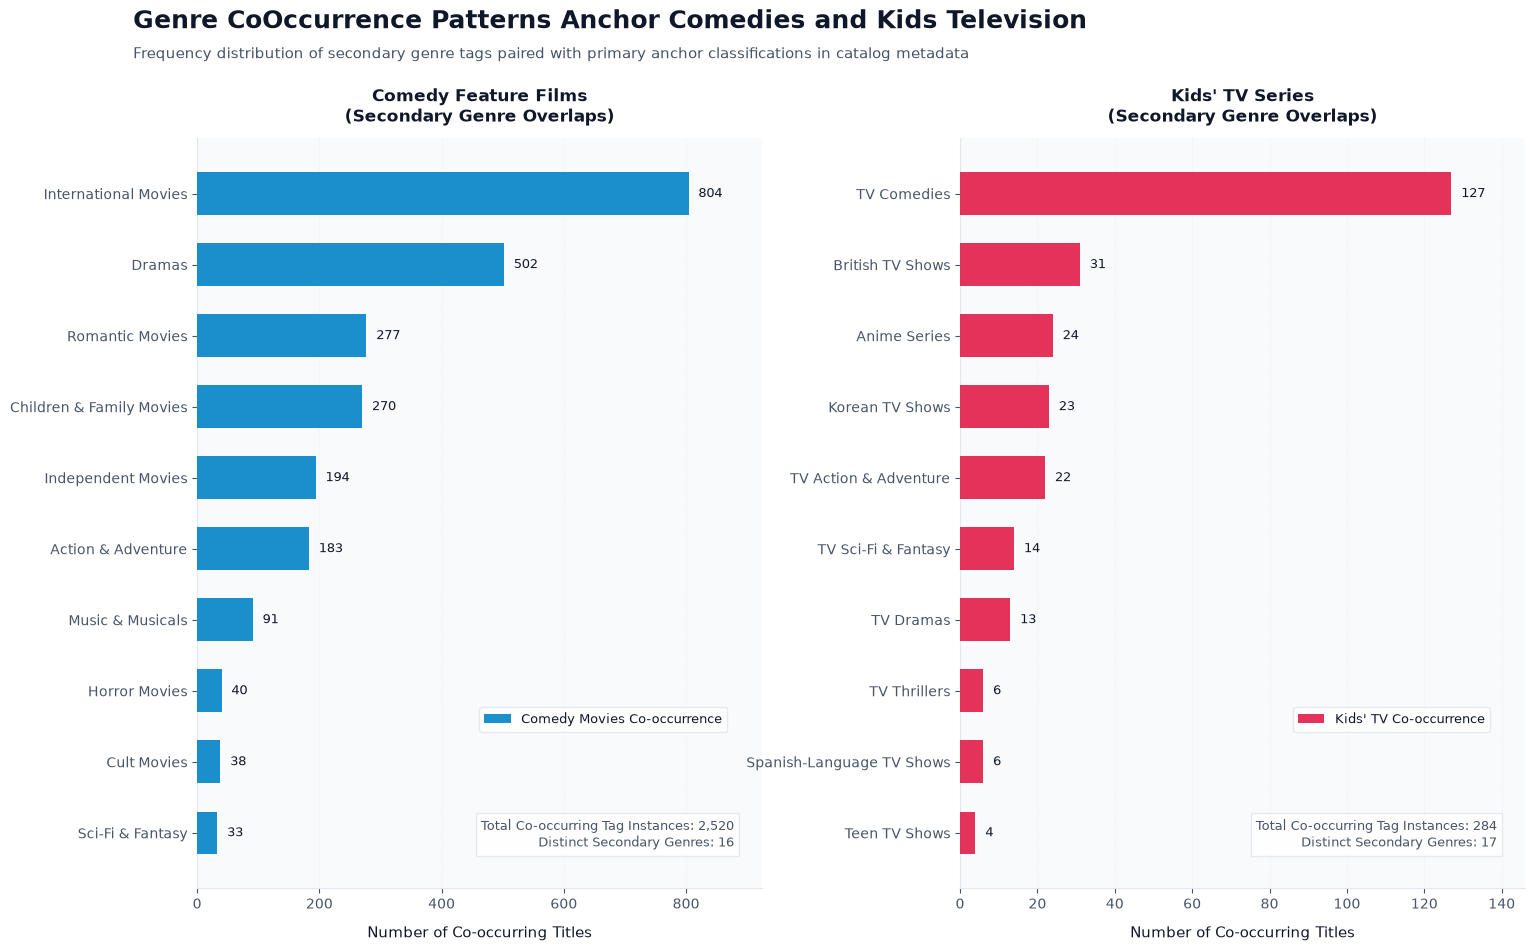

In [268]:
movie_df = pd.DataFrame(
    movie_comedy,
    columns=["Genre", "Count"],
)
tv_df = pd.DataFrame(
    tvshow_kids_tv,
    columns=["Genre", "Count"],
)

movie_top = movie_df.head(10).iloc[::-1].reset_index(drop=True)
tv_top = tv_df.head(10).iloc[::-1].reset_index(drop=True)

BG_COLOR = "#FFFFFF"
PANEL_BG = "#F8FAFC"
TEXT_COLOR = "#0F172A"
MUTED_TEXT = "#475569"
MOVIE_COLOR = "#0284C7"
TV_COLOR = "#E11D48"
GRID_COLOR = "#E2E8F0"

title_text = "Genre CoOccurrence Patterns Anchor Comedies and Kids Television"

fig = plt.figure(figsize=(16, 10), facecolor=BG_COLOR)
gs = fig.add_gridspec(1, 2, wspace=0.35)

ax0 = fig.add_subplot(gs[0], facecolor=PANEL_BG)
ax1 = fig.add_subplot(gs[1], facecolor=PANEL_BG)

bars0 = ax0.barh(
    movie_top["Genre"],
    movie_top["Count"],
    color=MOVIE_COLOR,
    height=0.6,
    alpha=0.9,
    zorder=3,
    label="Comedy Movies Co-occurrence",
)

max_movie_val = movie_top["Count"].max() if not movie_top.empty else 1
for bar, val in zip(bars0, movie_top["Count"]):
    ax0.text(
        val + (max_movie_val * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        ha="left",
        color=TEXT_COLOR,
        fontsize=9.5,
        fontweight="medium",
    )

ax0.set_xlabel(
    "Number of Co-occurring Titles", color=TEXT_COLOR, fontsize=11, labelpad=10
)
ax0.set_title(
    "Comedy Feature Films\n(Secondary Genre Overlaps)",
    color=TEXT_COLOR,
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax0.set_xlim(0, max_movie_val * 1.15)
ax0.grid(
    True,
    which="major",
    axis="x",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)

bars1 = ax1.barh(
    tv_top["Genre"],
    tv_top["Count"],
    color=TV_COLOR,
    height=0.6,
    alpha=0.9,
    zorder=3,
    label="Kids' TV Co-occurrence",
)

max_tv_val = tv_top["Count"].max() if not tv_top.empty else 1
for bar, val in zip(bars1, tv_top["Count"]):
    ax1.text(
        val + (max_tv_val * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        ha="left",
        color=TEXT_COLOR,
        fontsize=9.5,
        fontweight="medium",
    )

ax1.set_xlabel(
    "Number of Co-occurring Titles", color=TEXT_COLOR, fontsize=11, labelpad=10
)
ax1.set_title(
    "Kids' TV Series\n(Secondary Genre Overlaps)",
    color=TEXT_COLOR,
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax1.set_xlim(0, max_tv_val * 1.15)
ax1.grid(
    True,
    which="major",
    axis="x",
    linestyle=":",
    linewidth=0.5,
    color=GRID_COLOR,
    alpha=0.8,
)

for ax in [ax0, ax1]:
    ax.tick_params(colors=MUTED_TEXT, labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID_COLOR)
    ax.spines["bottom"].set_color(GRID_COLOR)

movie_total_co = movie_df["Count"].sum()
tv_total_co = tv_df["Count"].sum()

stats_str0 = f"Total Co-occurring Tag Instances: {movie_total_co:,}\nDistinct Secondary Genres: {len(movie_df)}"
stats_str1 = f"Total Co-occurring Tag Instances: {tv_total_co:,}\nDistinct Secondary Genres: {len(tv_df)}"

ax0.text(
    0.95,
    0.05,
    stats_str0,
    transform=ax0.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color=MUTED_TEXT,
    bbox={
        "boxstyle": "square,pad=0.4",
        "facecolor": BG_COLOR,
        "edgecolor": GRID_COLOR,
        "alpha": 0.9,
    },
)

ax1.text(
    0.95,
    0.05,
    stats_str1,
    transform=ax1.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color=MUTED_TEXT,
    bbox={
        "boxstyle": "square,pad=0.4",
        "facecolor": BG_COLOR,
        "edgecolor": GRID_COLOR,
        "alpha": 0.9,
    },
)

fig.text(
    0.08, 0.96, title_text, color=TEXT_COLOR, fontsize=18, fontweight="bold"
)
fig.text(
    0.08,
    0.93,
    "Frequency distribution of secondary genre tags paired with primary anchor classifications in catalog metadata",
    color=MUTED_TEXT,
    fontsize=11,
)

handles0, labels0 = ax0.get_legend_handles_labels()
ax0.legend(
    handles0,
    labels0,
    loc="lower right",
    bbox_to_anchor=(0.95, 0.2),
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=9.5,
    framealpha=0.9,
)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(
    handles1,
    labels1,
    loc="lower right",
    bbox_to_anchor=(0.95, 0.2),
    facecolor=BG_COLOR,
    edgecolor=GRID_COLOR,
    labelcolor=TEXT_COLOR,
    fontsize=9.5,
    framealpha=0.9,
)

plt.subplots_adjust(top=0.85, bottom=0.1, left=0.12, right=0.95)

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path, dpi=800, bbox_inches="tight", facecolor=fig.get_facecolor()
)


### 7. Acquisition Lag Investigation

In [269]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8807 non-null   str           
 1   type              8807 non-null   str           
 2   title             8807 non-null   str           
 3   director          8807 non-null   str           
 4   cast              8807 non-null   str           
 5   country           8807 non-null   str           
 6   date_added        8797 non-null   datetime64[us]
 7   release_year      8807 non-null   int64         
 8   rating            8807 non-null   str           
 9   duration          8807 non-null   str           
 10  listed_in         8807 non-null   str           
 11  description       8807 non-null   str           
 12  duration_minutes  6128 non-null   float64       
 13  duration_seasons  2676 non-null   float64       
 14  date_added_year   8797 non-null   f

In [270]:
df["release_year"] = pd.to_datetime(
    df["release_year"], format="%Y", errors="coerce"
)

In [271]:
target_cols = ["date_added", "release_year"]
released_added_diff = df[["title", "type"] + target_cols]
released_added_diff["added_year"] = released_added_diff["date_added"].dt.year
released_added_diff["published_in_days"] = np.abs(
    released_added_diff["release_year"] - released_added_diff["date_added"]
).dt.days

In [272]:
released_added_diff.head()

,title,type,date_added,release_year,added_year,published_in_days
0,Dick Johnson Is Dead,Movie,2021-09-25,2020-01-01,2021.0,633.0
1,Blood & Water,TV Show,2021-09-24,2021-01-01,2021.0,266.0
2,Ganglands,TV Show,2021-09-24,2021-01-01,2021.0,266.0
3,Jailbirds New Orleans,TV Show,2021-09-24,2021-01-01,2021.0,266.0
4,Kota Factory,TV Show,2021-09-24,2021-01-01,2021.0,266.0


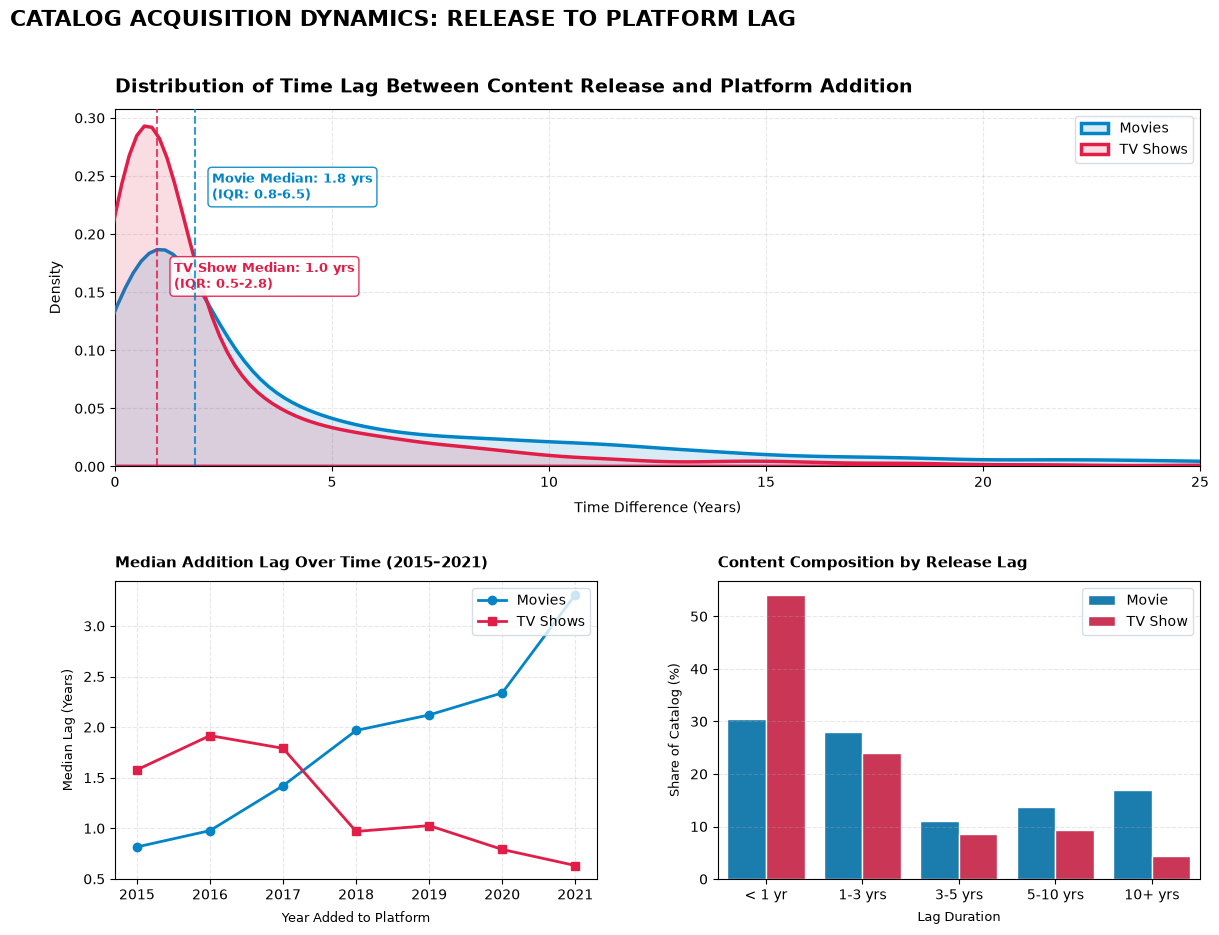

In [273]:
plot_df = released_added_diff.copy(deep=True)
plot_df = plot_df.dropna(subset=["published_in_days", "type", "added_year"])
plot_df["published_in_years"] = plot_df["published_in_days"] / 365.25
plot_df = plot_df[
    (plot_df["published_in_years"] >= 0) & (plot_df["published_in_years"] <= 30)
]

movies = plot_df[plot_df["type"].str.lower() == "movie"]["published_in_years"]
tv_shows = plot_df[plot_df["type"].str.lower() == "tv show"][
    "published_in_years"
]

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(
    2, 2, height_ratios=[1.2, 1], width_ratios=[1, 1], hspace=0.35, wspace=0.25
)

ax_main = fig.add_subplot(gs[0, :])
ax_sub1 = fig.add_subplot(gs[1, 0])
ax_sub2 = fig.add_subplot(gs[1, 1])

for ax in [ax_main, ax_sub1, ax_sub2]:
    ax.tick_params(labelsize=10)
    ax.grid(True, linestyle="--", alpha=0.3, zorder=0)

sns.kdeplot(
    data=movies,
    ax=ax_main,
    color="#0284C7",
    linewidth=2.5,
    label="Movies",
    fill=True,
    alpha=0.15,
    zorder=3,
)
sns.kdeplot(
    data=tv_shows,
    ax=ax_main,
    color="#E11D48",
    linewidth=2.5,
    label="TV Shows",
    fill=True,
    alpha=0.15,
    zorder=3,
)

m_med, m_q1, m_q3 = (
    movies.median(),
    movies.quantile(0.25),
    movies.quantile(0.75),
)
tv_med, tv_q1, tv_q3 = (
    tv_shows.median(),
    tv_shows.quantile(0.25),
    tv_shows.quantile(0.75),
)

ax_main.axvline(
    m_med, color="#0284C7", linestyle="--", linewidth=1.5, alpha=0.8, zorder=4
)
ax_main.axvline(
    tv_med, color="#E11D48", linestyle="--", linewidth=1.5, alpha=0.8, zorder=4
)

ax_main.text(
    m_med + 0.4,
    ax_main.get_ylim()[1] * 0.75,
    f"Movie Median: {m_med:.1f} yrs\n(IQR: {m_q1:.1f}-{m_q3:.1f})",
    color="#0284C7",
    fontsize=9.5,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.3",
        "facecolor": "white",
        "edgecolor": "#0284C7",
        "alpha": 0.9,
    },
)
ax_main.text(
    tv_med + 0.4,
    ax_main.get_ylim()[1] * 0.50,
    f"TV Show Median: {tv_med:.1f} yrs\n(IQR: {tv_q1:.1f}-{tv_q3:.1f})",
    color="#E11D48",
    fontsize=9.5,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.3",
        "facecolor": "white",
        "edgecolor": "#E11D48",
        "alpha": 0.9,
    },
)

ax_main.set_title(
    "Distribution of Time Lag Between Content Release and Platform Addition",
    fontsize=14,
    fontweight="bold",
    pad=12,
    loc="left",
)
ax_main.set_xlabel("Time Difference (Years)", fontsize=10, labelpad=8)
ax_main.set_ylabel("Density", fontsize=10, labelpad=8)
ax_main.set_xlim(0, 25)
ax_main.legend(
    edgecolor="#CBD5E1",
    loc="upper right",
)

yearly_lag = (
    plot_df[plot_df["added_year"] >= 2015]
    .groupby(["added_year", "type"])["published_in_years"]
    .median()
    .unstack()
)

if "Movie" in yearly_lag.columns:
    ax_sub1.plot(
        yearly_lag.index,
        yearly_lag["Movie"],
        marker="o",
        linewidth=2,
        color="#0284C7",
        label="Movies",
    )
if "TV Show" in yearly_lag.columns:
    ax_sub1.plot(
        yearly_lag.index,
        yearly_lag["TV Show"],
        marker="s",
        linewidth=2,
        color="#E11D48",
        label="TV Shows",
    )

ax_sub1.set_title(
    "Median Addition Lag Over Time (2015–2021)",
    fontsize=11,
    fontweight="bold",
    pad=10,
    loc="left",
)
ax_sub1.set_xlabel("Year Added to Platform", fontsize=9, labelpad=6)
ax_sub1.set_ylabel("Median Lag (Years)", fontsize=9, labelpad=6)
ax_sub1.legend(
    edgecolor="#CBD5E1",
    loc="upper right",
)

recent_df = plot_df[plot_df["added_year"] >= 2017].copy()
recent_df["lag_category"] = pd.cut(
    recent_df["published_in_years"],
    bins=[-0.1, 1, 3, 5, 10, 100],
    labels=["< 1 yr", "1-3 yrs", "3-5 yrs", "5-10 yrs", "10+ yrs"],
)

cat_counts = (
    recent_df.groupby(["type", "lag_category"], observed=False)["title"]
    .count()
    .to_frame(name="count")
)
cat_counts["percentage"] = cat_counts.groupby(level="type")["count"].transform(
    lambda x: 100 * x / float(x.sum())
)
cat_counts = cat_counts.reset_index()

sns.barplot(
    data=cat_counts,
    x="lag_category",
    y="percentage",
    hue="type",
    ax=ax_sub2,
    palette={"Movie": "#0284C7", "TV Show": "#E11D48"},
    edgecolor="white",
)

ax_sub2.set_title(
    "Content Composition by Release Lag",
    fontsize=11,
    fontweight="bold",
    pad=10,
    loc="left",
)
ax_sub2.set_xlabel("Lag Duration", fontsize=9, labelpad=6)
ax_sub2.set_ylabel("Share of Catalog (%)", fontsize=9, labelpad=6)
ax_sub2.legend(
    edgecolor="#CBD5E1",
    loc="upper right",
)

fig.suptitle(
    "CATALOG ACQUISITION DYNAMICS: RELEASE TO PLATFORM LAG",
    fontsize=16,
    fontweight="bold",
    y=0.98,
    x=0.05,
    ha="left",
)

title_text = "Catalog Acquisition Dynamics Release to Platform Lag"

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path, dpi=800, bbox_inches="tight", facecolor=fig.get_facecolor()
)

### 8. The Duplicate Description Anomaly

In [274]:
duplicates = df[df["description"].duplicated(keep=False)].reset_index(drop=True)

In [275]:
duplicates

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons,date_added_year,date_added_month,date_added_day
0,s52,Movie,InuYasha the Movie 2: The Castle Beyond the Lo...,Toshiya Shinohara,"Kappei Yamaguchi, Satsuki Yukino, Mieko Harada...",Japan,2021-09-15,2002-01-01,TV-14,99 min,"Action & Adventure, Anime Features, Internatio...","With their biggest foe seemingly defeated, Inu...",99.0,NaN,2021.0,9.0,15.0
1,s53,Movie,InuYasha the Movie 3: Swords of an Honorable R...,Toshiya Shinohara,"Kappei Yamaguchi, Satsuki Yukino, Koji Tsujita...",Japan,2021-09-15,2003-01-01,TV-14,99 min,"Action & Adventure, Anime Features, Internatio...",The Great Dog Demon beaqueathed one of the Thr...,99.0,NaN,2021.0,9.0,15.0
2,s57,Movie,Naruto Shippuden the Movie: Blood Prison,Masahiko Murata,"Junko Takeuchi, Chie Nakamura, Rikiya Koyama, ...",Japan,2021-09-15,2011-01-01,TV-14,102 min,"Action & Adventure, Anime Features, Internatio...",Mistakenly accused of an attack on the Fourth ...,102.0,NaN,2021.0,9.0,15.0
3,s79,Movie,Tughlaq Durbar,Delhiprasad Deenadayalan,"Vijay Sethupathi, Parthiban, Raashi Khanna",unrecorded,2021-09-11,2020-01-01,TV-14,145 min,"Comedies, Dramas, International Movies",A budding politician has devious plans to rise...,145.0,NaN,2021.0,9.0,11.0
4,s80,Movie,Tughlaq Durbar (Telugu),Delhiprasad Deenadayalan,"Vijay Sethupathi, Parthiban, Raashi Khanna",unrecorded,2021-09-11,2021-01-01,TV-14,145 min,"Comedies, Dramas, International Movies",A budding politician has devious plans to rise...,145.0,NaN,2021.0,9.0,11.0
5,s237,Movie,Boomika,Rathindran R Prasad,"Aishwarya Rajesh, Vidhu, Surya Ganapathy, Madh...",unrecorded,2021-08-23,2021-01-01,TV-14,122 min,"Horror Movies, International Movies, Thrillers","Paranormal activity at a lush, abandoned prope...",122.0,NaN,2021.0,8.0,23.0
6,s238,Movie,Boomika (Hindi),Rathindran R Prasad,"Aishwarya Rajesh, Vidhu, Surya Ganapathy, Madh...",unrecorded,2021-08-23,2021-01-01,TV-14,122 min,"Horror Movies, International Movies, Thrillers","Paranormal activity at a lush, abandoned prope...",122.0,NaN,2021.0,8.0,23.0
7,s239,Movie,Boomika (Malayalam),Rathindran R Prasad,"Aishwarya Rajesh, Vidhu, Surya Ganapathy, Madh...",unrecorded,2021-08-23,2021-01-01,TV-14,122 min,"Horror Movies, International Movies, Thrillers","Paranormal activity at a lush, abandoned prope...",122.0,NaN,2021.0,8.0,23.0
8,s240,Movie,Boomika (Telugu),Rathindran R Prasad,"Aishwarya Rajesh, Vidhu, Surya Ganapathy, Madh...",unrecorded,2021-08-23,2021-01-01,TV-14,122 min,"Horror Movies, International Movies, Thrillers","Paranormal activity at a lush, abandoned prope...",122.0,NaN,2021.0,8.0,23.0
9,s304,Movie,Esperando la carroza,Alejandro Doria,"Luis Brandoni, China Zorrilla, Antonio Gasalla...",Argentina,2021-08-05,1985-01-01,TV-MA,95 min,"Comedies, Cult Movies, International Movies",Cora has three sons and a daughter and she´s a...,95.0,NaN,2021.0,8.0,5.0


In [276]:
# NOTE: 1. SAME TITLE
# Same underlying title after accounting for title variations.
same_title = [
    "s52",
    "s7091",  # InuYasha Movie 2
    "s53",
    "s7090",  # InuYasha Movie 3
    "s304",
    "s6706",  # Esperando la carroza
    "s3372",
    "s6530",  # Consequences
    "s1271",
    "s8023",  # Sin senos sí hay paraíso
]

# NOTE: TRANSLATIONS / LANGUAGE VERSIONS
# Same or essentially same content appearing in another language
# or language version.
translations = [
    "s79",
    "s80",
    "s237",  # Boomika
    "s238",  # Boomika (Hindi)
    "s239",  # Boomika (Malalayam)
    "s240",  # Boomika (Telugu)
    "s852",  # 99 Songs (Tamil)
    "s853",  # 99 Songs (Telugu)
    "s851",  # Oh! Baby
    "s1653",
    "s1654",
    "s2335",
    "s2336",
    "s2337",
    "s3494",  # Oh! Baby (Tamil)
    "s3517",  # Oh! Baby (Tamil)
    "s2569",
    "s2570",
    "s3569",
    "s3570",  # Game Over (Hindi / Tamil)
    "s3933",
    "s4062",  # Sarvam Thaala Mayam (Telugu / Tamil)
    "s3934",
    "s3940",  # Petta (Telugu / original)
    "s8052",
    "s8053",  # Solo: A Star Wars Story / Spanish Version
    "s7068",
    "s8361",  # The Incredibles 2 / Spanish Version
]

# NOTE: POSSIBLE TRANSLATIONS / REMAKES / ALTERNATE VERSIONS
# These look related, but the evidence is not strong enough to
# automatically treat them exactly like translations.
possible_translations = [
    "s1983",
    "s1987",  # Anaamika / Nee Enge En Anbe
    "s2841",
    "s2874",  # Angu Vaikuntapurathu / Ala Vaikunthapurramuloo
]


# NOTE: EXACT / VERY STRONG METADATA DUPLICATES
# Records where essentially all meaningful metadata is the same
# and the records appear to be duplicate entries.
exact_metadata_duplicates = [
    "s3372",
    "s6530",  # Consequences
    "s3963",
    "s5967",  # 15 August
    "s3997",
    "s5965",  # February 9 / Feb-09
    "s4523",
    "s5966",  # 22 July / 22-Jul
    "s8052",
    "s8053",  # Solo: A Star Wars Story
]


In [277]:
same_title_indices = duplicates[
    duplicates["show_id"].isin(values=same_title)
].index

duplicates = duplicates.drop(same_title_indices)


translation_to_other_languages = duplicates[
    duplicates["show_id"].isin(values=translations)
].index

duplicates = duplicates.drop(translation_to_other_languages)


possible_translation_indices = duplicates[
    duplicates["show_id"].isin(values=possible_translations)
].index

duplicates = duplicates.drop(possible_translation_indices)


# NOTE: The only data rows that can be droppped in main DataFrame. But there are not too many of them
# So I will just keep them too.
exact_metadata_duplicate_indices = duplicates[
    duplicates["show_id"].isin(values=exact_metadata_duplicates)
].index

duplicates = duplicates.drop(exact_metadata_duplicate_indices)

In [278]:
duplicates.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons,date_added_year,date_added_month,date_added_day
2,s57,Movie,Naruto Shippuden the Movie: Blood Prison,Masahiko Murata,"Junko Takeuchi, Chie Nakamura, Rikiya Koyama, ...",Japan,2021-09-15,2011-01-01,TV-14,102 min,"Action & Adventure, Anime Features, Internatio...",Mistakenly accused of an attack on the Fourth ...,102.0,NaN,2021.0,9.0,15.0
18,s2271,Movie,Chashme Baddoor,David Dhawan,"Rishi Kapoor, Ali Zafar, Taapsee Pannu, Siddha...",India,2020-07-05,2013-01-01,TV-14,121 min,"Comedies, International Movies, Music & Musicals",When pretty new neighbor Seema falls for their...,121.0,NaN,2020.0,7.0,5.0
22,s2665,TV Show,ChuChu TV Nursery Rhymes & Kids Songs (Hindi),unrecorded,unrecorded,India,2020-04-18,2019-01-01,TV-Y,1 Season,Kids' TV,This educational series for tiny tots features...,NaN,1.0,2020.0,4.0,18.0
25,s2970,Movie,Together For Eternity,Sooraj R. Barjatya,"Salman Khan, Karisma Kapoor, Saif Ali Khan, Ta...",India,2020-02-01,1999-01-01,TV-G,176 min,"Dramas, International Movies, Music & Musicals",A scheming matriarch plots to cut off her disa...,176.0,NaN,2020.0,2.0,1.0
26,s3029,TV Show,The Ollie & Moon Show,unrecorded,"Mattea Conforti, Kobi Frumer",France,2020-01-14,2018-01-01,TV-Y,1 Season,Kids' TV,"Two quirky cats, Ollie and Moon, and their fri...",NaN,1.0,2020.0,1.0,14.0


### 9. Director Cadence Analysis

In [279]:
df_directors = df.copy(deep=True)
unrecorder_directors = df[df["director"] == "unrecorded"].index
df_directors = df_directors.drop(unrecorder_directors)

df_directors["director"] = df_directors["director"].str.strip().str.split(",")

df_directors = df_directors.explode(column="director", ignore_index=True)

In [280]:
df_directors["director"].sample(5)

4109      Joaquín Mazón
6403       Kurt Voelker
3628    Johan Brisinger
3570     Laura Brownson
6391         Rob Reiner
Name: director, dtype: str

In [281]:
top_directors_by_titles = (
    df_directors.groupby("director")
    .agg(titles=("show_id", "count"))
    .sort_values(
        by="titles",
        ascending=False,
    )
    .reset_index()
)

top_directors_by_titles = top_directors_by_titles[
    top_directors_by_titles["titles"] >= 8
].director.to_list()

df_directors = df_directors[
    df_directors["director"].isin(top_directors_by_titles)
].reset_index()


In [282]:
for row in df_directors.itertuples():
    director_titles = df_directors[df_directors["director"] == row.director][
        ["director", "title", "release_year"]
    ]

    years = sorted(
        director_titles["release_year"].dt.year.dropna().astype(int).tolist()
    )

    total_gap = 0
    for i in range(1, len(years)):
        total_gap += years[i] - years[i - 1]

    if len(years) > 1:
        avg_gap = np.round(total_gap / (len(years) - 1), 3)
    else:
        avg_gap = 0.0  # 0 gap if they only have 1 movie

    df_directors.loc[row.Index, "avg_gap_years"] = avg_gap


In [283]:
df_directors.head()

,index,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons,date_added_year,date_added_month,date_added_day,avg_gap_years
0,29,s42,Movie,Jaws,Steven Spielberg,"Roy Scheider, Robert Shaw, Richard Dreyfuss, L...",United States,2021-09-16,1975-01-01,PG,124 min,"Action & Adventure, Classic Movies, Dramas",When an insatiable great white shark terrorize...,124.0,NaN,2021.0,9.0,16.0,4.100
1,161,s206,Movie,Kyo Kii... Main Jhuth Nahin Bolta,David Dhawan,"Govinda, Sushmita Sen, Rambha, Anupam Kher, Sa...",India,2021-08-27,2001-01-01,TV-14,150 min,"Comedies, International Movies, Sci-Fi & Fantasy",The life and career of a lawyer are thrown int...,150.0,NaN,2021.0,8.0,27.0,2.500
2,256,s330,Movie,Catch Me If You Can,Steven Spielberg,"Leonardo DiCaprio, Tom Hanks, Christopher Walk...","United States, Canada",2021-08-01,2002-01-01,PG-13,142 min,Dramas,An FBI agent makes it his mission to put cunni...,142.0,NaN,2021.0,8.0,1.0,4.100
3,305,s393,Movie,Django Unchained,Quentin Tarantino,"Jamie Foxx, Christoph Waltz, Leonardo DiCaprio...",United States,2021-07-24,2012-01-01,R,165 min,"Action & Adventure, Dramas","Accompanied by a German bounty hunter, a freed...",165.0,NaN,2021.0,7.0,24.0,3.000
4,313,s407,Movie,Chhota Bheem - Neeli Pahaadi,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",unrecorded,2021-07-22,2013-01-01,TV-Y7,64 min,Children & Family Movies,Things get spooky when Bheem and his buddies t...,64.0,NaN,2021.0,7.0,22.0,0.476


In [284]:
df_directors["avg_gap_days"] = np.round(df_directors["avg_gap_years"] * 365, 0)
df_directors = df_directors[
    [
        "show_id",
        "title",
        "director",
        "avg_gap_years",
        "avg_gap_days",
    ]
]

In [285]:
df_directors = (
    df_directors.groupby(by=["director", "avg_gap_years", "avg_gap_days"])
    .agg(titles=("show_id", "count"))
    .reset_index()
)

In [286]:
original_df = df.copy()

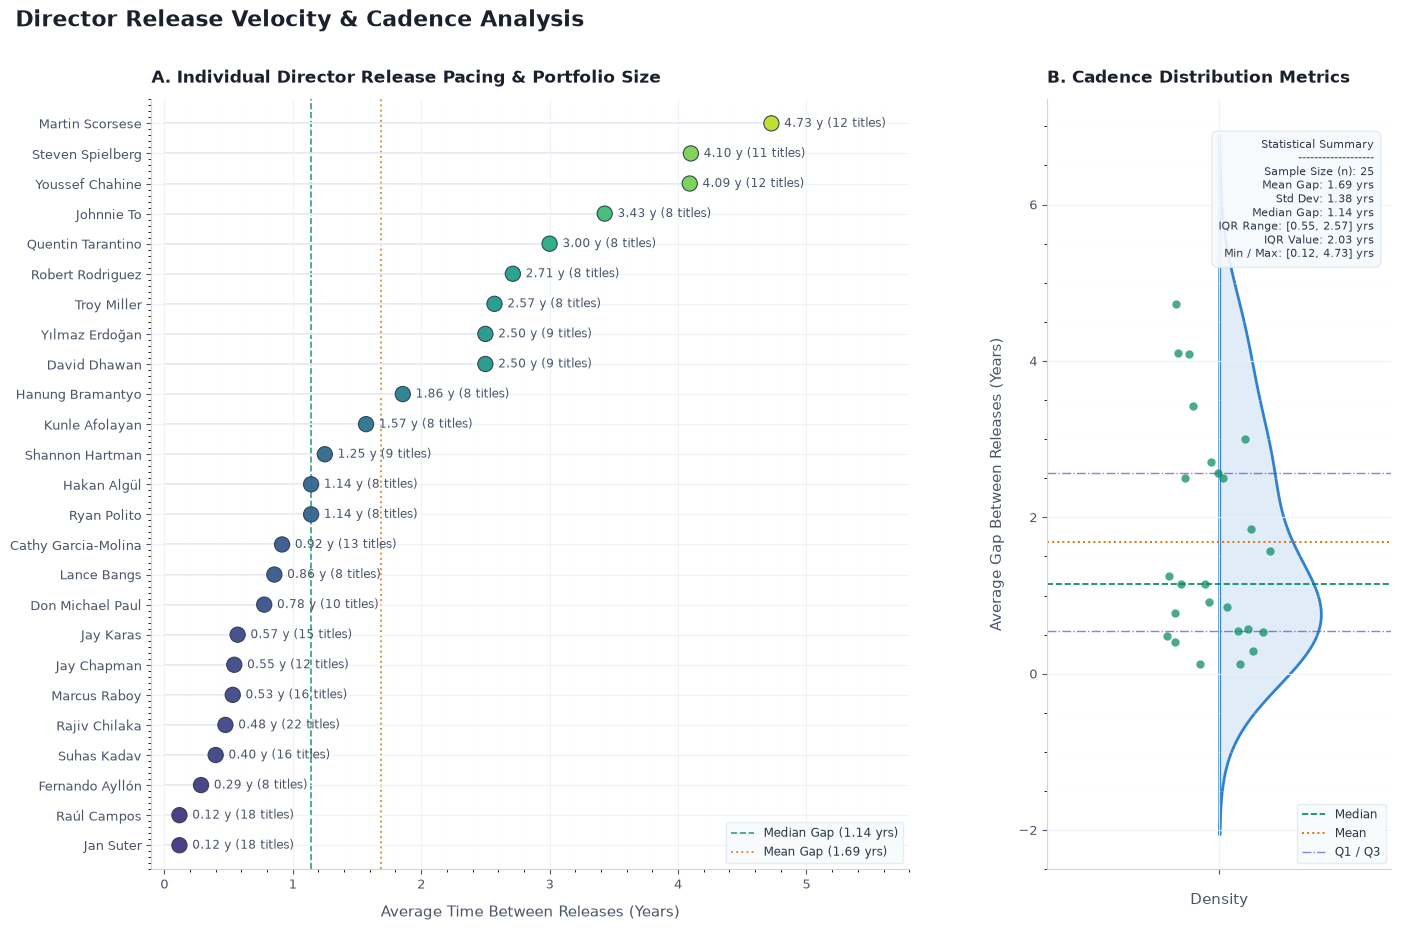

In [287]:
df = df_directors.copy(deep=True)
title_text = "Director Release Velocity & Cadence Analysis"

fig = plt.figure(figsize=(16, 10), facecolor="#FFFFFF")
gs = fig.add_gridspec(1, 2, width_ratios=[2.2, 1.0], wspace=0.25)

ax1 = fig.add_subplot(gs[0], facecolor="#FFFFFF")
ax2 = fig.add_subplot(gs[1], facecolor="#FFFFFF")

df_sorted = df_directors.sort_values(
    "avg_gap_years", ascending=True
).reset_index(drop=True)

y_positions = np.arange(len(df_sorted))
gaps = df_sorted["avg_gap_years"].values
titles_count = df_sorted["titles"].values

norm_gaps = (gaps - gaps.min()) / (
    gaps.max() - gaps.min() if gaps.max() > gaps.min() else 1
)
cmap = plt.cm.viridis
colors = cmap(0.15 + 0.75 * norm_gaps)

ax1.hlines(
    y=y_positions,
    xmin=0,
    xmax=gaps,
    color="#E0E6ED",
    linewidth=1.2,
    zorder=1,
)

# Scatter plot with fixed marker size for all points
scatter = ax1.scatter(
    gaps,
    y_positions,
    s=120,
    c=colors,
    edgecolor="#2C3E50",
    linewidth=0.8,
    zorder=2,
    alpha=0.95,
)

for y, (gap, count) in enumerate(zip(gaps, titles_count)):
    ax1.text(
        gap + 0.1,
        y,
        f"{gap:.2f} y ({count} titles)",
        va="center",
        ha="left",
        fontsize=8.5,
        color="#4A5568",
        fontweight="normal",
    )

mean_gap = df["avg_gap_years"].mean()
median_gap = df["avg_gap_years"].median()

ax1.axvline(
    x=median_gap,
    color="#00875A",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    zorder=0,
    label=f"Median Gap ({median_gap:.2f} yrs)",
)
ax1.axvline(
    x=mean_gap,
    color="#D97706",
    linestyle=":",
    linewidth=1.4,
    alpha=0.8,
    zorder=0,
    label=f"Mean Gap ({mean_gap:.2f} yrs)",
)

ax1.set_yticks(y_positions)
ax1.set_yticklabels(df_sorted["director"], fontsize=9.5, color="#1A202C")
ax1.set_xlabel(
    "Average Time Between Releases (Years)",
    fontsize=10.5,
    color="#4A5568",
    labelpad=10,
)
ax1.set_xlim(-0.1, 5.8)
ax1.set_ylim(-0.8, len(df_sorted) - 0.2)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color("#CBD5E0")
ax1.spines["bottom"].set_color("#CBD5E0")
ax1.tick_params(colors="#4A5568", labelsize=9)

# Grid lines (major and minor)
ax1.minorticks_on()
ax1.grid(
    which="major",
    axis="both",
    color="#EDF2F7",
    linestyle="-",
    linewidth=0.8,
    alpha=0.9,
)
ax1.grid(
    which="minor",
    axis="x",
    color="#F7FAFC",
    linestyle=":",
    linewidth=0.5,
    alpha=0.7,
)

ax1.set_title(
    "A. Individual Director Release Pacing & Portfolio Size",
    fontsize=12,
    color="#1A202C",
    weight="bold",
    loc="left",
    pad=12,
)

sns.kdeplot(
    y=df["avg_gap_years"],
    ax=ax2,
    color="#3182CE",
    linewidth=2,
    fill=True,
    alpha=0.15,
)

sns.stripplot(
    y=df["avg_gap_years"],
    ax=ax2,
    color="#00875A",
    size=6,
    jitter=0.18,
    alpha=0.7,
    zorder=3,
)

q1 = df["avg_gap_years"].quantile(0.25)
q3 = df["avg_gap_years"].quantile(0.75)
iqr = q3 - q1
std_dev = df["avg_gap_years"].std()
min_val = df["avg_gap_years"].min()
max_val = df["avg_gap_years"].max()
sample_n = len(df)

ax2.axhline(
    median_gap, color="#00875A", linestyle="--", linewidth=1.2, label="Median"
)
ax2.axhline(
    mean_gap, color="#D97706", linestyle=":", linewidth=1.4, label="Mean"
)
ax2.axhline(
    q1,
    color="#6B46C1",
    linestyle="-.",
    linewidth=1.0,
    alpha=0.7,
    label="Q1 / Q3",
)
ax2.axhline(q3, color="#6B46C1", linestyle="-.", linewidth=1.0, alpha=0.7)

ax2.set_ylabel(
    "Average Gap Between Releases (Years)",
    fontsize=10.5,
    color="#4A5568",
    labelpad=10,
)
ax2.set_xlabel("Density", fontsize=10.5, color="#4A5568", labelpad=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color("#CBD5E0")
ax2.spines["bottom"].set_color("#CBD5E0")
ax2.tick_params(colors="#4A5568", labelsize=9)

# Grid lines (major and minor)
ax2.minorticks_on()
ax2.grid(
    which="major",
    axis="both",
    color="#EDF2F7",
    linestyle="-",
    linewidth=0.8,
    alpha=0.9,
)
ax2.grid(
    which="minor",
    axis="y",
    color="#F7FAFC",
    linestyle=":",
    linewidth=0.5,
    alpha=0.7,
)

ax2.set_title(
    "B. Cadence Distribution Metrics",
    fontsize=12,
    color="#1A202C",
    weight="bold",
    loc="left",
    pad=12,
)

# Render statistical metrics as clear formatted plain text
stats_text = (
    f"Statistical Summary\n"
    f"-------------------\n"
    f"Sample Size (n): {int(sample_n)}\n"
    f"Mean Gap: {mean_gap:.2f} yrs\n"
    f"Std Dev: {std_dev:.2f} yrs\n"
    f"Median Gap: {median_gap:.2f} yrs\n"
    f"IQR Range: [{q1:.2f}, {q3:.2f}] yrs\n"
    f"IQR Value: {iqr:.2f} yrs\n"
    f"Min / Max: [{min_val:.2f}, {max_val:.2f}] yrs"
)

ax2.text(
    0.95,
    0.95,
    stats_text,
    transform=ax2.transAxes,
    fontsize=8.0,
    color="#2D3748",
    fontfamily="sans-serif",
    verticalalignment="top",
    horizontalalignment="right",
    bbox={
        "boxstyle": "round,pad=0.6",
        "facecolor": "#F7FAFC",
        "edgecolor": "#E2E8F0",
        "alpha": 0.9,
    },
)

fig.suptitle(
    title_text,
    fontsize=16,
    color="#1A202C",
    weight="bold",
    x=0.04,
    y=0.97,
    ha="left",
)

ax1.legend(
    loc="lower right",
    facecolor="#F7FAFC",
    edgecolor="#E2E8F0",
    fontsize=8.5,
    labelcolor="#2D3748",
)
ax2.legend(
    loc="lower right",
    facecolor="#F7FAFC",
    edgecolor="#E2E8F0",
    fontsize=8.5,
    labelcolor="#2D3748",
)

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path, dpi=800, bbox_inches="tight", facecolor=fig.get_facecolor()
)

In [288]:
df = original_df.copy()

### 10. Target Audience Cohort Mapping

In [289]:
df["rating"].value_counts()

rating
TV-MA         3207
TV-14         2160
TV-PG          863
R              799
PG-13          490
TV-Y7          334
TV-Y           307
PG             287
TV-G           220
NR              80
G               41
TV-Y7-FV         6
unrecorded       4
NC-17            3
UR               3
74 min           1
84 min           1
66 min           1
Name: count, dtype: int64

In [290]:
target_vals = ["TV-MA", "TV-14", "TV-PG", "R"]

df_audience = df[["show_id", "release_year", "rating"]]
df_audience = df_audience[df_audience["rating"].isin(target_vals)]
df_audience["release_year"] = df["release_year"].dt.year

In [291]:
df_audience.head()

,show_id,release_year,rating
1,s2,2021,TV-MA
2,s3,2021,TV-MA
3,s4,2021,TV-MA
4,s5,2021,TV-MA
5,s6,2021,TV-MA


In [292]:
cohort = df_audience.groupby(by="release_year").agg(
    TV_MA=("rating", lambda rating: (rating == "TV-MA").sum()),
    TV_14=("rating", lambda rating: (rating == "TV-14").sum()),
    TV_PG=("rating", lambda rating: (rating == "TV-PG").sum()),
    R=("rating", lambda rating: (rating == "R").sum()),
)

In [293]:
cohort.head()

,TV_MA,TV_14,TV_PG,R
release_year,,,,
1925,0,1,0,0
1942,0,2,0,0
1943,0,0,3,0
1944,0,2,1,0
1945,2,2,0,0


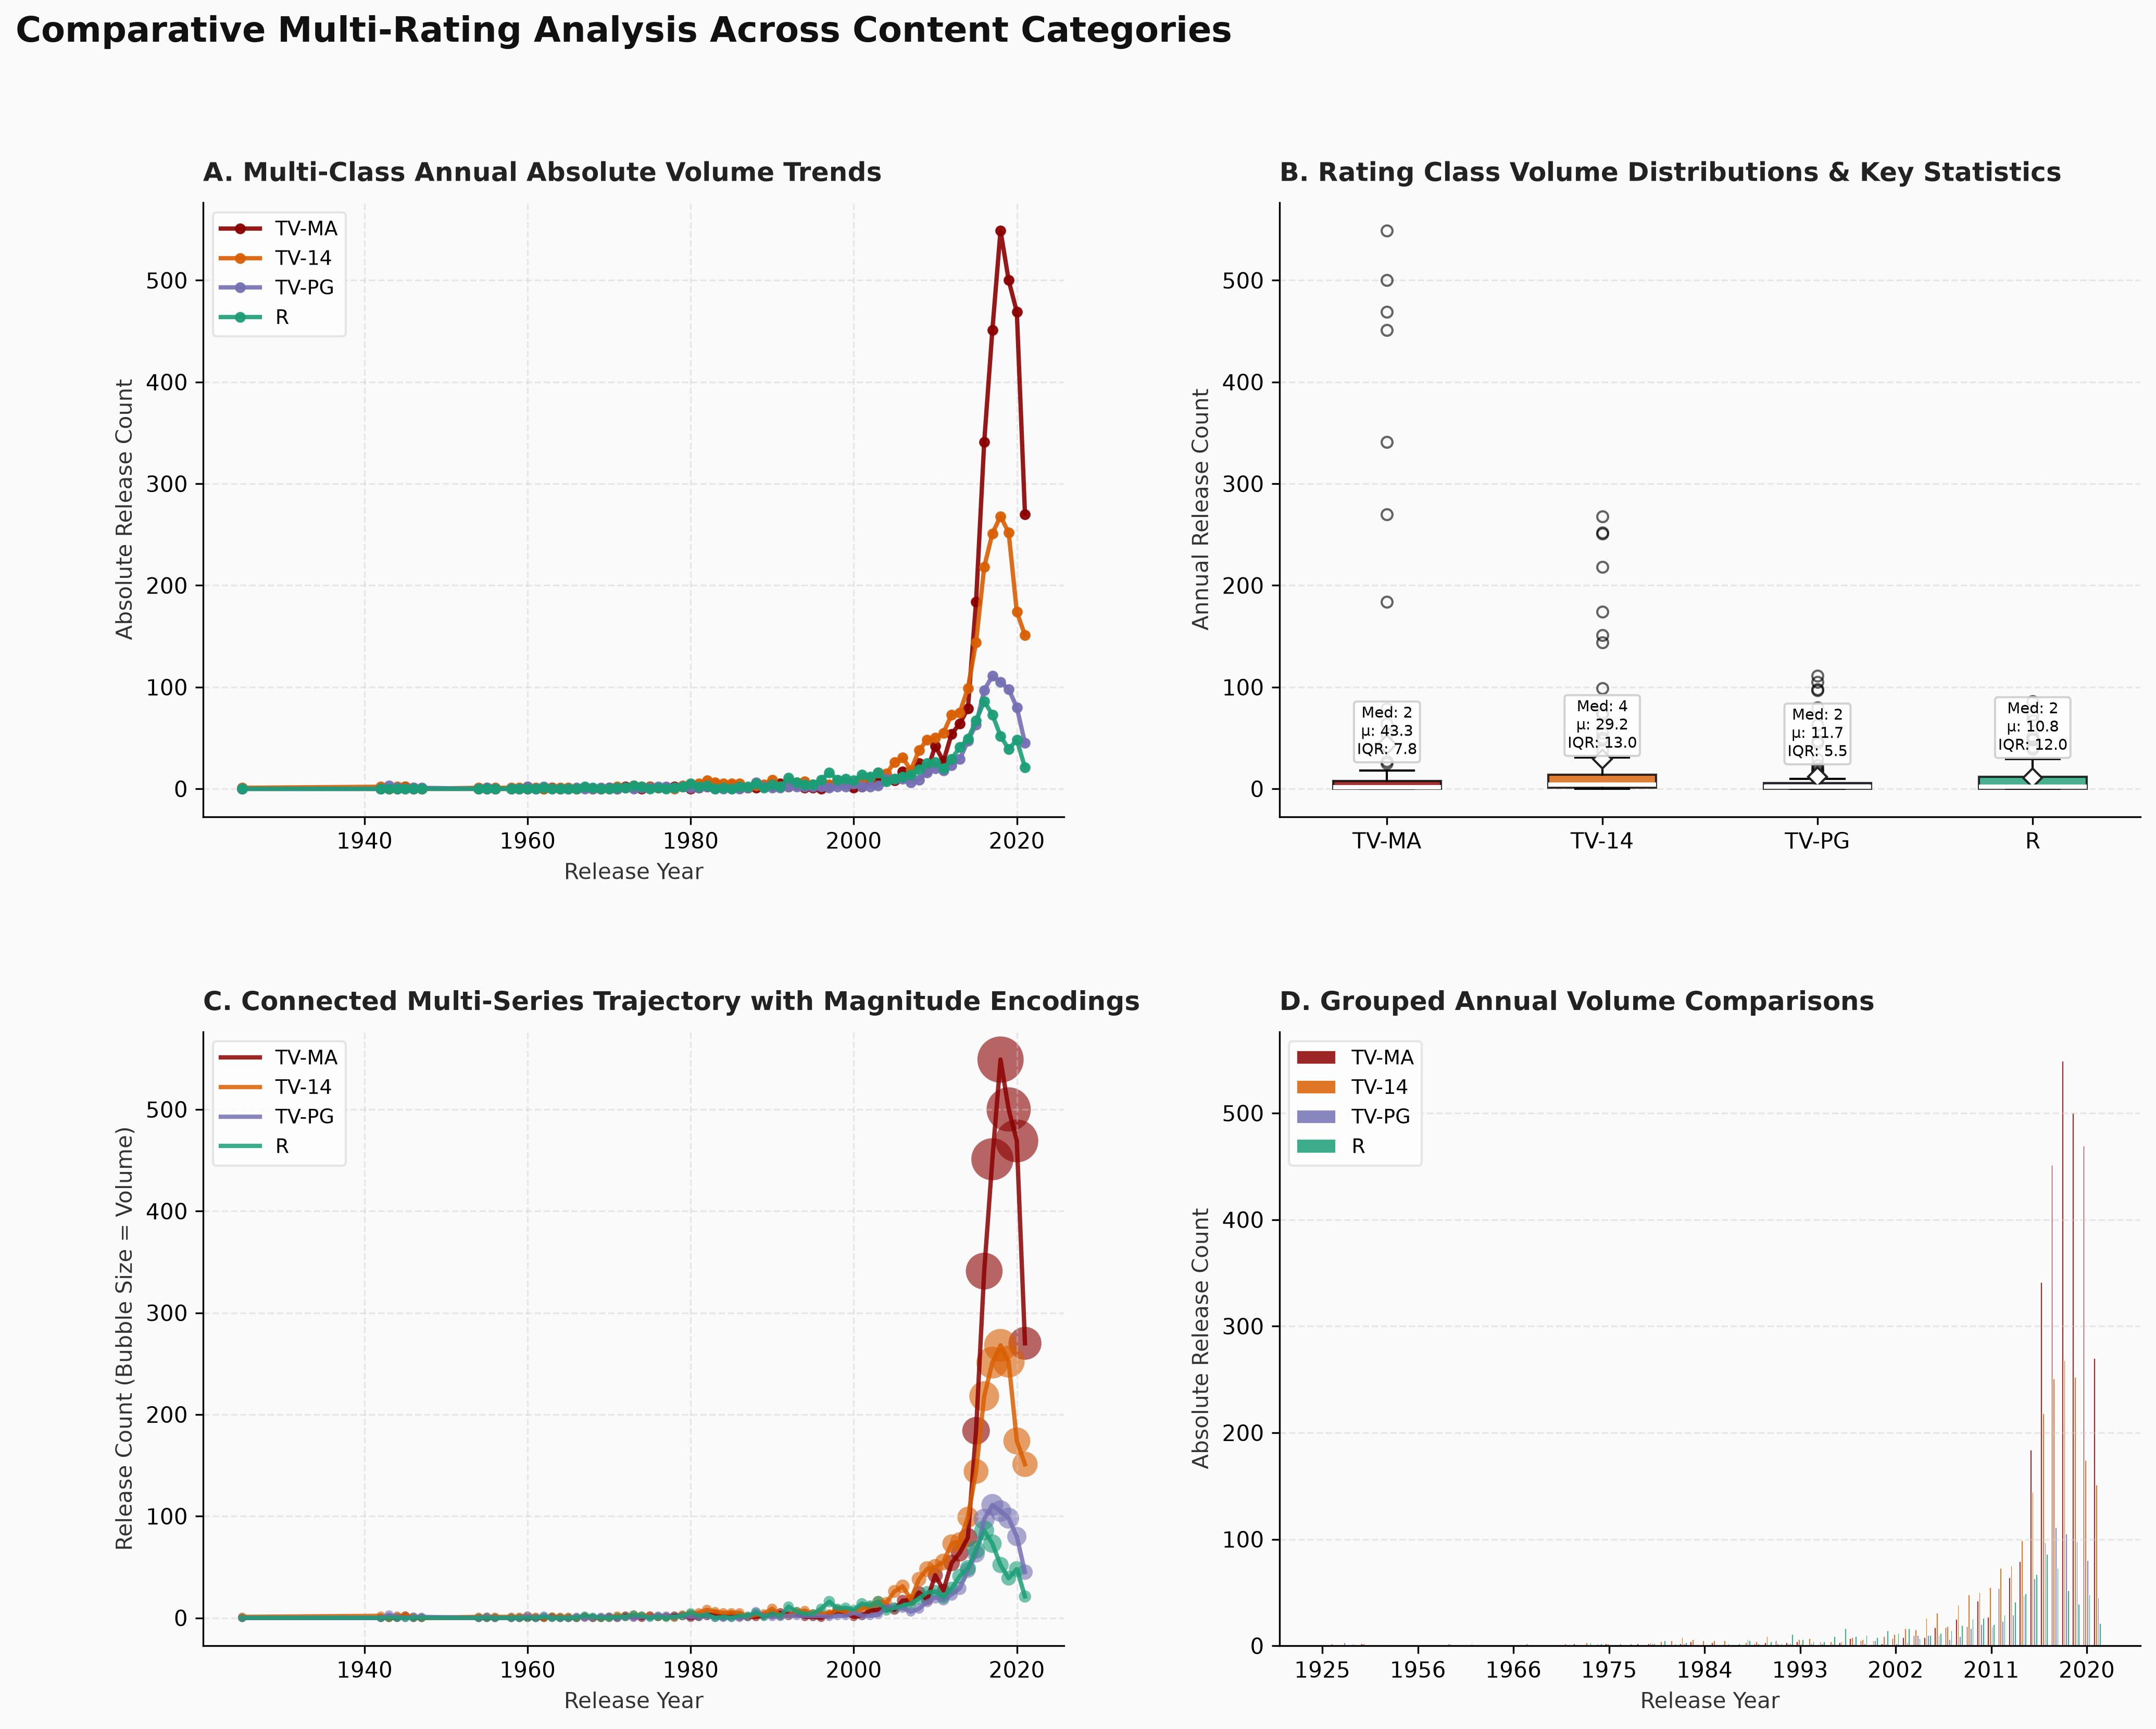

In [294]:
ratings = cohort.columns.tolist()

colors = {
    "TV_MA": "#8B0000",
    "TV_14": "#D95F02",
    "TV_PG": "#7570B3",
    "R": "#1B9E77",
}

labels_map = {
    "TV_MA": "TV-MA",
    "TV_14": "TV-14",
    "TV_PG": "TV-PG",
    "R": "R",
}

years = cohort.index.values

fig, axes = plt.subplots(
    nrows=2, ncols=2, figsize=(16, 12), dpi=300, facecolor="#FAFAFA"
)
fig.subplots_adjust(hspace=0.35, wspace=0.25)

ax1, ax2, ax3, ax4 = axes.flatten()
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor("#FAFAFA")

for rating in ratings:
    counts = cohort[rating].values
    color = colors.get(rating, "#333333")
    label = labels_map.get(rating, rating)

    ax1.plot(
        years,
        counts,
        marker="o",
        markersize=4,
        linewidth=2,
        color=color,
        label=label,
        alpha=0.9,
    )

ax1.set_title(
    "A. Multi-Class Annual Absolute Volume Trends",
    fontsize=12,
    fontweight="bold",
    pad=10,
    loc="left",
    color="#222222",
)
ax1.set_xlabel("Release Year", fontsize=10, color="#333333")
ax1.set_ylabel("Absolute Release Count", fontsize=10, color="#333333")
ax1.grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(
    loc="upper left",
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="#E0E0E0",
    fontsize=9,
)

box_data = [cohort[r].values for r in ratings]
box_colors = [colors.get(r, "#333333") for r in ratings]

bplot = ax2.boxplot(
    box_data,
    patch_artist=True,
    tick_labels=[labels_map.get(r, r) for r in ratings],
    widths=0.5,
    medianprops={"color": "#FFFFFF", "linewidth": 2},
    flierprops={"marker": "o", "markersize": 5, "alpha": 0.6},
)

for patch, color in zip(bplot["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

for i, rating in enumerate(ratings, start=1):
    vals = cohort[rating].values
    mean_val = np.mean(vals)
    median_val = np.median(vals)
    q25, q75 = np.percentile(vals, [25, 75])
    iqr_val = q75 - q25
    ax2.plot(
        i,
        mean_val,
        marker="D",
        color="#FFFFFF",
        markeredgecolor="#222222",
        markersize=6,
    )
    ax2.annotate(
        f"Med: {median_val:.0f}\nμ: {mean_val:.1f}\nIQR: {iqr_val:.1f}",
        xy=(i, q75),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=7,
        bbox={
            "boxstyle": "round,pad=0.2",
            "facecolor": "#FFFFFF",
            "alpha": 0.85,
            "edgecolor": "#CCCCCC",
        },
    )

ax2.set_title(
    "B. Rating Class Volume Distributions & Key Statistics",
    fontsize=12,
    fontweight="bold",
    pad=10,
    loc="left",
    color="#222222",
)
ax2.set_ylabel("Annual Release Count", fontsize=10, color="#333333")
ax2.grid(True, axis="y", linestyle="--", alpha=0.4, color="#CCCCCC")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

for rating in ratings:
    counts = cohort[rating].values
    color = colors.get(rating, "#333333")
    label = labels_map.get(rating, rating)

    ax3.plot(
        years,
        counts,
        linewidth=2,
        color=color,
        label=label,
        alpha=0.85,
    )
    ax3.scatter(
        years,
        counts,
        s=counts * 0.8 + 15,
        color=color,
        alpha=0.6,
        edgecolors="none",
    )

ax3.set_title(
    "C. Connected Multi-Series Trajectory with Magnitude Encodings",
    fontsize=12,
    fontweight="bold",
    pad=10,
    loc="left",
    color="#222222",
)
ax3.set_xlabel("Release Year", fontsize=10, color="#333333")
ax3.set_ylabel(
    "Release Count (Bubble Size = Volume)", fontsize=10, color="#333333"
)
ax3.grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.legend(
    loc="upper left",
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="#E0E0E0",
    fontsize=9,
)

x_coords = np.arange(len(years))
width = 0.18

for i, rating in enumerate(ratings):
    counts = cohort[rating].values
    color = colors.get(rating, "#333333")
    label = labels_map.get(rating, rating)

    ax4.bar(
        x_coords + i * width,
        counts,
        width=width,
        color=color,
        label=label,
        alpha=0.85,
        edgecolor="#FFFFFF",
        linewidth=0.5,
    )

step = max(1, len(years) // 8)
ax4.set_xticks(x_coords[::step] + width * 1.5)
ax4.set_xticklabels(years[::step], rotation=0)

ax4.set_title(
    "D. Grouped Annual Volume Comparisons",
    fontsize=12,
    fontweight="bold",
    pad=10,
    loc="left",
    color="#222222",
)
ax4.set_xlabel("Release Year", fontsize=10, color="#333333")
ax4.set_ylabel("Absolute Release Count", fontsize=10, color="#333333")
ax4.grid(True, axis="y", linestyle="--", alpha=0.4, color="#CCCCCC")
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
ax4.legend(
    loc="upper left",
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="#E0E0E0",
    fontsize=9,
)

title_text = "Comparative Multi-Rating Analysis Across Content Categories"
fig.suptitle(
    title_text,
    fontsize=16,
    fontweight="bold",
    y=0.98,
    x=0.05,
    ha="left",
    color="#111111",
)

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path, dpi=800, bbox_inches="tight", facecolor=fig.get_facecolor()
)


### 11. TV Show Longevity Metrics

In [295]:
tv_shows = df[df["type"] == "TV Show"][["show_id", "release_year", "duration"]]
tv_shows["release_year"] = tv_shows["release_year"].dt.year
tv_shows["duration"] = (
    tv_shows["duration"].str.slice(start=0, stop=2).astype(int)
)

In [296]:
tv_shows.head()

,show_id,release_year,duration
1,s2,2021,2
2,s3,2021,1
3,s4,2021,1
4,s5,2021,2
5,s6,2021,1


In [297]:
longevity = (
    tv_shows.groupby(by="release_year")
    .agg(avg_duration=("duration", "mean"))
    .round(2)
)

In [298]:
longevity.head()

,avg_duration
release_year,
1925,1.0
1945,1.0
1946,1.0
1963,4.0
1967,8.0


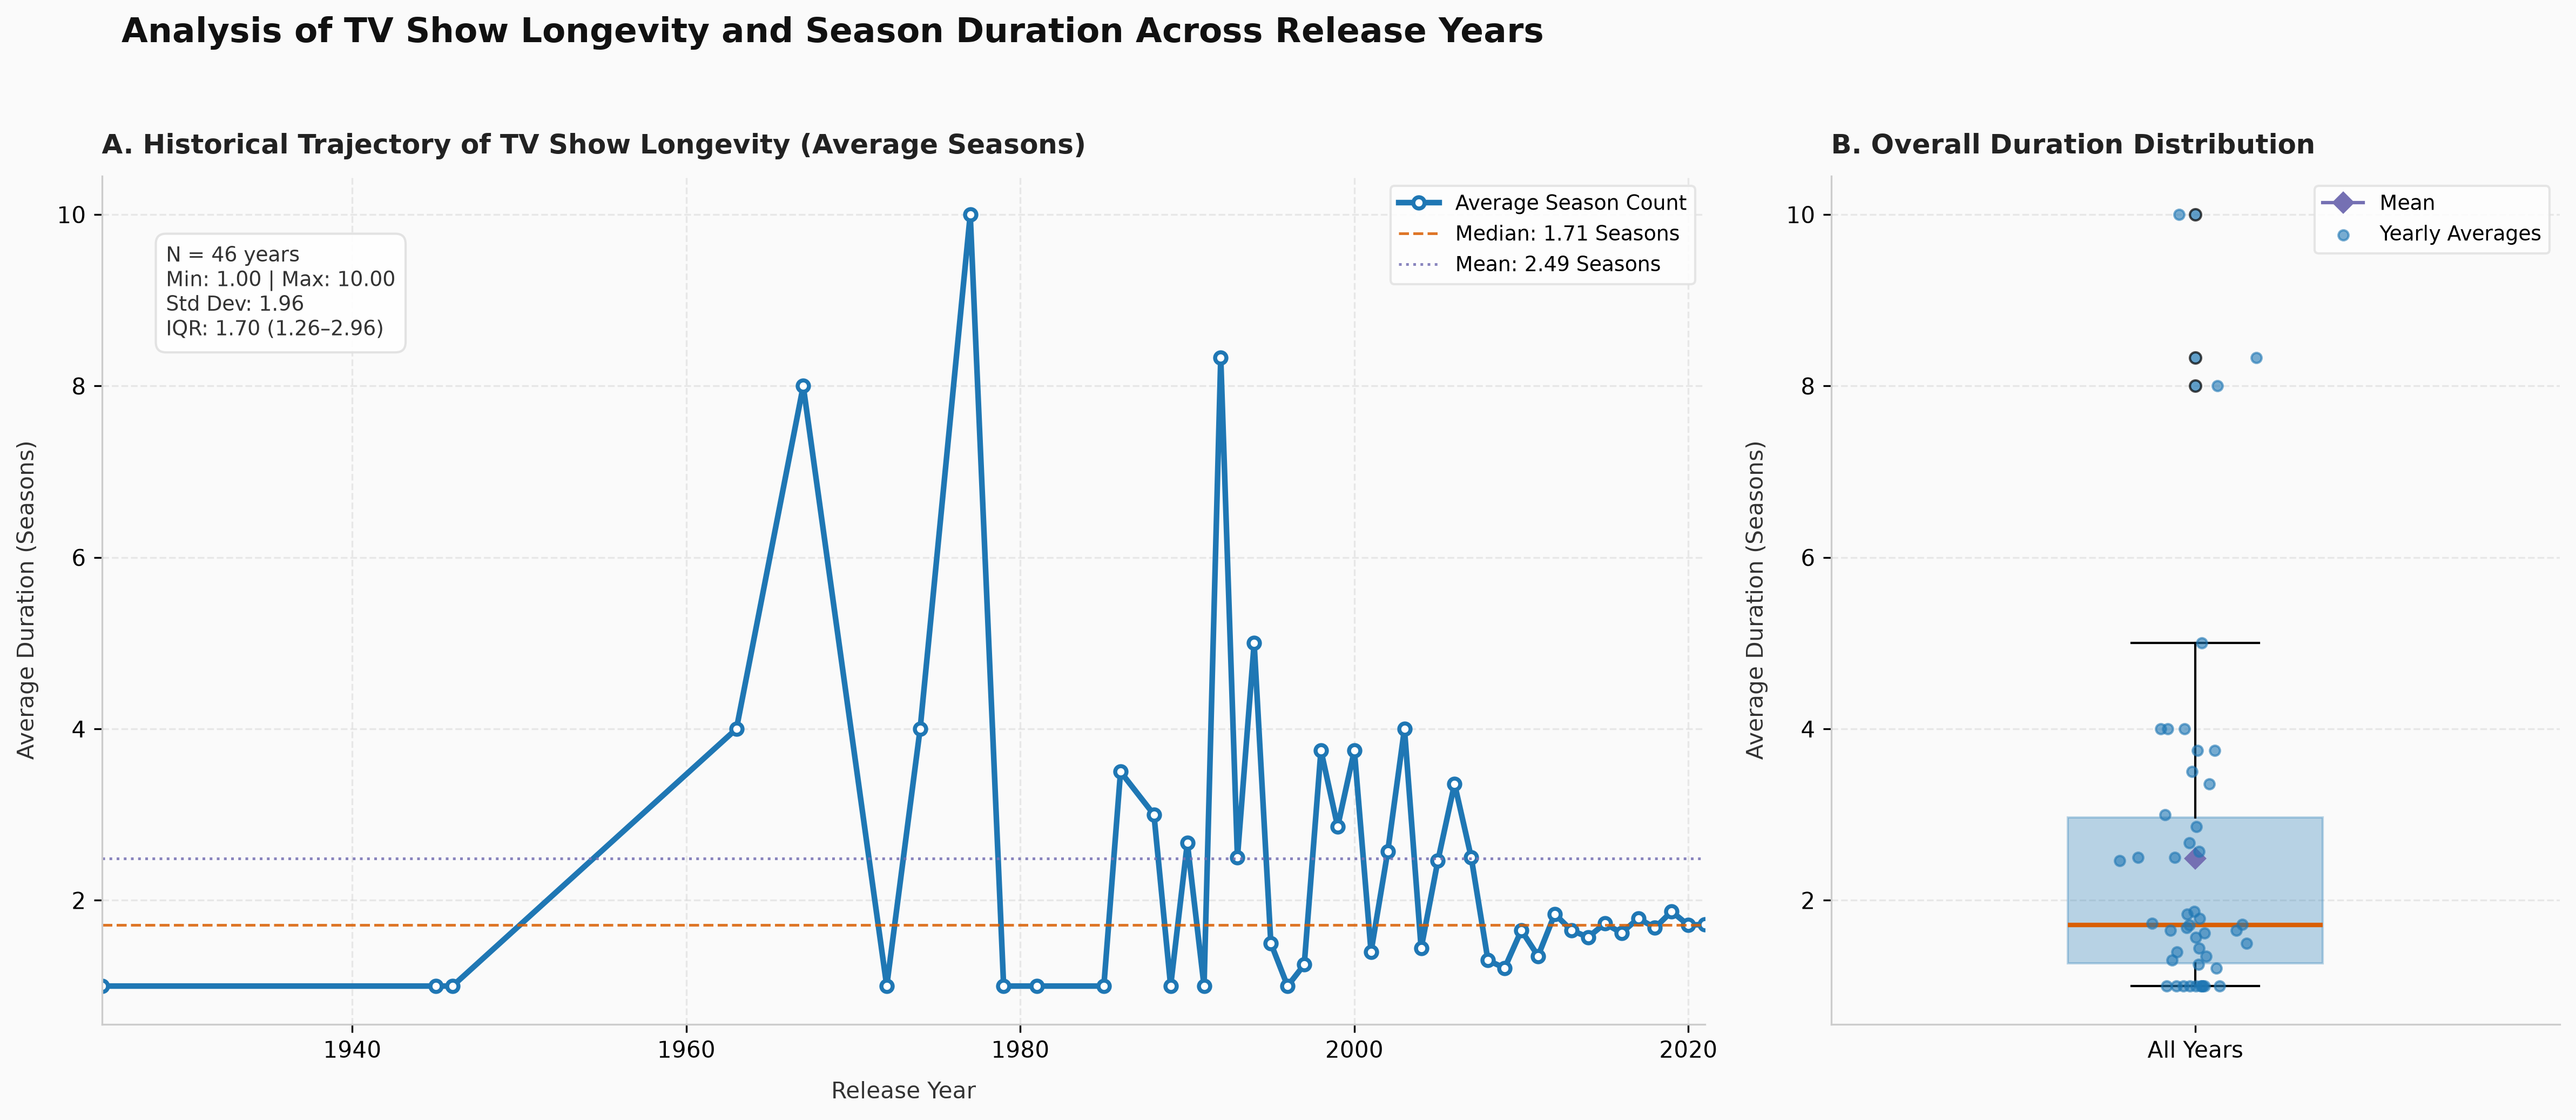

In [299]:
years = longevity.index.values
durations = longevity["avg_duration"].values

fig, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 7),
    dpi=300,
    facecolor="#FAFAFA",
    gridspec_kw={"width_ratios": [2.2, 1]},
)

ax1.set_facecolor("#FAFAFA")
ax2.set_facecolor("#FAFAFA")

ax1.plot(
    years,
    durations,
    color="#1F77B4",
    linewidth=2.5,
    marker="o",
    markersize=5,
    markerfacecolor="#FFFFFF",
    markeredgewidth=1.8,
    label="Average Season Count",
)

mean_val = np.mean(durations)
median_val = np.median(durations)
std_val = np.std(durations)
q25, q75 = np.percentile(durations, [25, 75])
iqr_val = q75 - q25
min_val, max_val = np.min(durations), np.max(durations)
sample_n = len(durations)

ax1.axhline(
    median_val,
    color="#D95F02",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    label=f"Median: {median_val:.2f} Seasons",
)
ax1.axhline(
    mean_val,
    color="#7570B3",
    linestyle=":",
    linewidth=1.2,
    alpha=0.85,
    label=f"Mean: {mean_val:.2f} Seasons",
)

ax1.set_title(
    "A. Historical Trajectory of TV Show Longevity (Average Seasons)",
    fontsize=12,
    fontweight="bold",
    pad=10,
    loc="left",
    color="#222222",
)
ax1.set_xlabel("Release Year", fontsize=10, color="#333333", labelpad=8)
ax1.set_ylabel(
    "Average Duration (Seasons)", fontsize=10, color="#333333", labelpad=8
)
ax1.set_xlim(years.min(), years.max())
ax1.grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color("#CCCCCC")
ax1.spines["bottom"].set_color("#CCCCCC")

stats_text = (
    f"N = {sample_n} years\n"
    f"Min: {min_val:.2f} | Max: {max_val:.2f}\n"
    f"Std Dev: {std_val:.2f}\n"
    f"IQR: {iqr_val:.2f} ({q25:.2f}–{q75:.2f})"
)
ax1.text(
    0.04,
    0.92,
    stats_text,
    transform=ax1.transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "#FFFFFF",
        "edgecolor": "#E0E0E0",
        "alpha": 0.9,
    },
    color="#333333",
)
ax1.legend(
    loc="upper right",
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="#E0E0E0",
    fontsize=9,
)

bplot = ax2.boxplot(
    [durations],
    patch_artist=True,
    tick_labels=["All Years"],
    widths=0.35,
    medianprops={"color": "#D95F02", "linewidth": 2},
    flierprops={
        "marker": "o",
        "markersize": 5,
        "alpha": 0.7,
        "markerfacecolor": "#1F77B4",
    },
)

for patch in bplot["boxes"]:
    patch.set_facecolor("#1F77B4")
    patch.set_alpha(0.3)
    patch.set_edgecolor("#1F77B4")

ax2.plot(
    1,
    mean_val,
    marker="D",
    color="#7570B3",
    markersize=6,
    label="Mean",
)

jitter = np.random.normal(1, 0.03, size=len(durations))
ax2.scatter(
    jitter,
    durations,
    color="#1F77B4",
    alpha=0.6,
    s=20,
    zorder=3,
    label="Yearly Averages",
)

ax2.set_title(
    "B. Overall Duration Distribution",
    fontsize=12,
    fontweight="bold",
    pad=10,
    loc="left",
    color="#222222",
)
ax2.set_ylabel(
    "Average Duration (Seasons)", fontsize=10, color="#333333", labelpad=8
)
ax2.grid(True, axis="y", linestyle="--", alpha=0.4, color="#CCCCCC")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color("#CCCCCC")
ax2.spines["bottom"].set_color("#CCCCCC")
ax2.legend(
    loc="upper right",
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="#E0E0E0",
    fontsize=9,
)

title_text = (
    "Analysis of TV Show Longevity and Season Duration Across Release Years"
)
fig.suptitle(
    title_text,
    fontsize=15,
    fontweight="bold",
    y=0.98,
    x=0.05,
    ha="left",
    color="#111111",
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path, dpi=800, bbox_inches="tight", facecolor=fig.get_facecolor()
)


### 12. Cast Member Geographic Centrality

In [300]:
cast = df.copy(deep=True)
cast["cast"] = cast["cast"].str.strip().str.split(",")
cast = cast.explode(column="cast", ignore_index=True)

rows_to_drop = cast[cast["cast"] == "unrecorded"].index

cast["cast"] = cast["cast"].drop(rows_to_drop)
cast["cast"] = cast["cast"].dropna()

In [301]:
cast["country"] = cast["country"].str.strip().str.split(",")
cast = cast.explode(column="country", ignore_index=True)
rows_to_drop = cast[cast["country"] == "unrecorded"].index
cast["country"] = cast["country"].drop(rows_to_drop)

In [302]:
cast.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons,date_added_year,date_added_month,date_added_day
28812,s2946,TV Show,Cagaster of an Insect Cage,unrecorded,Daiki Yamashita,Japan,2020-02-06,2020-01-01,TV-MA,1 Season,"Anime Series, International TV Shows",Thirty years after a disease that turns the in...,NaN,1.0,2020.0,2.0,6.0
62540,s6858,TV Show,Glowing Embers,unrecorded,Alvin Wong,NaN,2017-08-14,2010-01-01,TV-14,1 Season,"International TV Shows, TV Dramas","Amid Malaysia's charcoal industry, a woman def...",NaN,1.0,2017.0,8.0,14.0
33268,s3421,TV Show,Second 20s,unrecorded,Kim Min-jae,South Korea,2019-10-16,2015-01-01,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...","Facing major changes, a mother realizes it's t...",NaN,1.0,2019.0,10.0,16.0
36546,s3822,TV Show,Dennis and Gnasher Unleashed,unrecorded,Kelly Marie Stewart,United Kingdom,2019-05-15,2017-01-01,TV-Y,1 Season,"British TV Shows, Kids' TV, TV Comedies","Fearless Dennis, his loyal dog Gnasher and bes...",NaN,1.0,2019.0,5.0,15.0
47178,s5107,Movie,Bibi & Tina: Tohuwabohu Total,Detlev Buck,Martin Seifert,Germany,2017-12-27,2017-01-01,TV-14,106 min,"Children & Family Movies, Music & Musicals",Teen witch Bibi and her pal Tina return to the...,106.0,NaN,2017.0,12.0,27.0


In [303]:
cast = (
    cast.groupby(by="cast")
    .agg(
        titles=("show_id", "count"),
        unique_countries=("country", "nunique"),
    )
    .sort_values(by="titles", ascending=False)
)

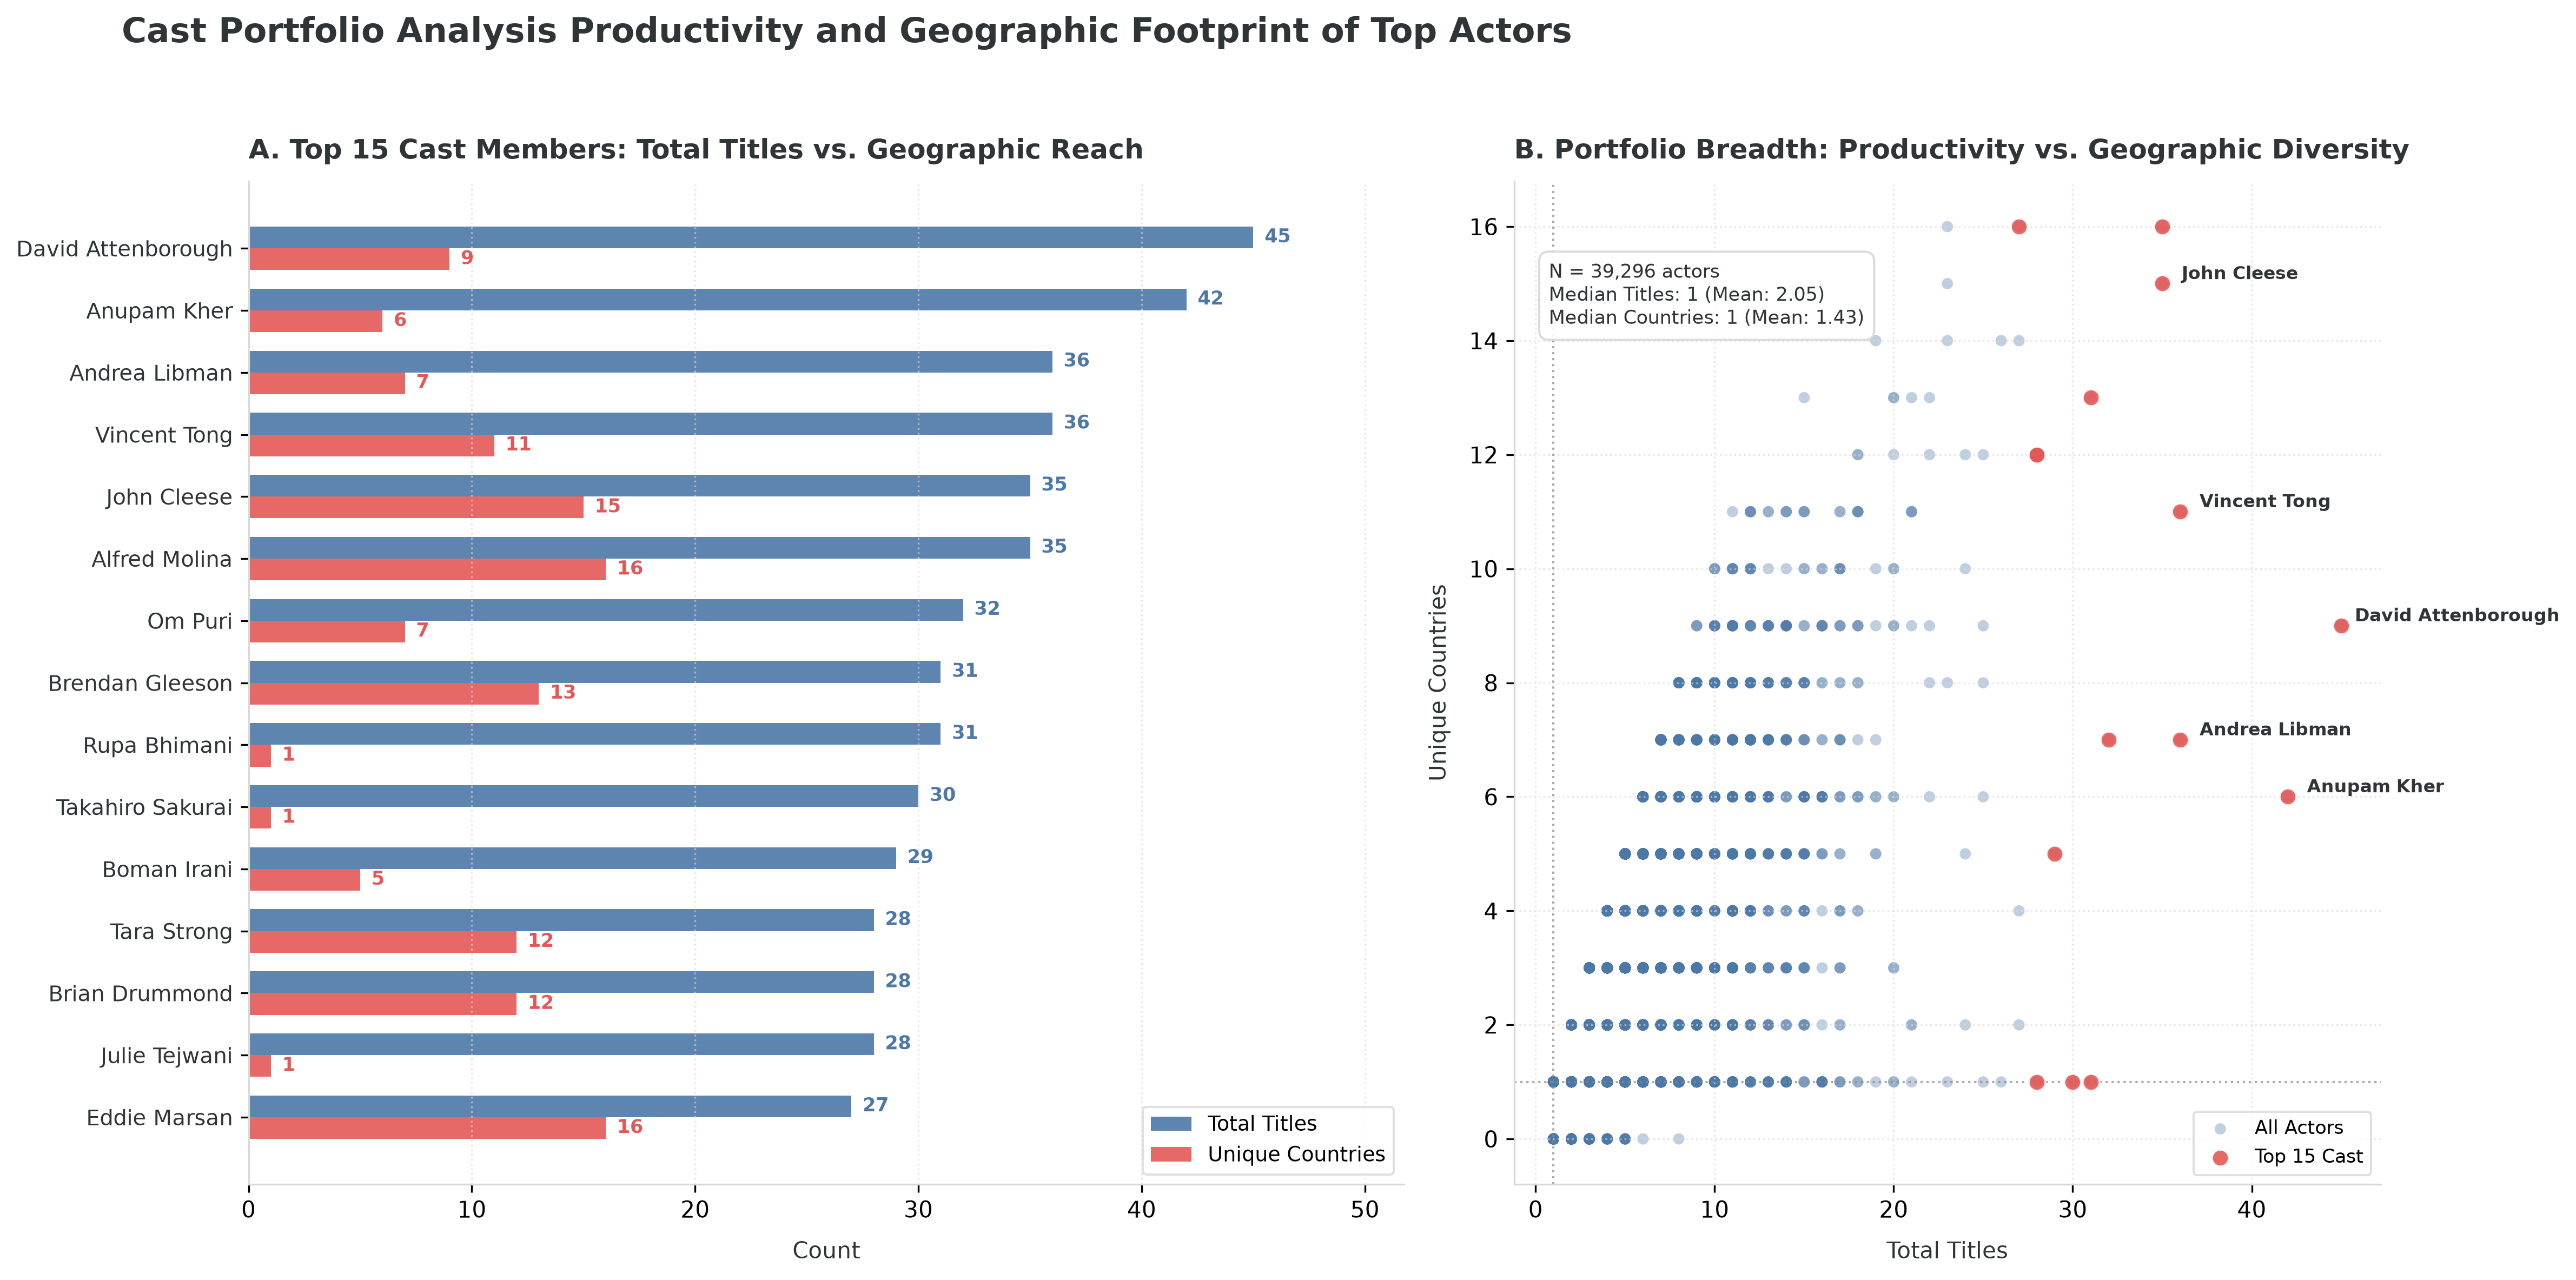

In [304]:
top_cast = cast.head(15).iloc[::-1]

names = top_cast.index.values
titles = top_cast["titles"].values
countries = top_cast["unique_countries"].values

all_titles = cast["titles"].values
all_countries = cast["unique_countries"].values

fig, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 8),
    dpi=300,
    facecolor="#FFFFFF",
    gridspec_kw={"width_ratios": [1.6, 1.2]},
)

ax1.set_facecolor("#FFFFFF")
ax2.set_facecolor("#FFFFFF")

y_pos = np.arange(len(names))
height = 0.35

rects1 = ax1.barh(
    y_pos + height / 2,
    titles,
    height=height,
    color="#4C78A8",
    alpha=0.9,
    label="Total Titles",
)

rects2 = ax1.barh(
    y_pos - height / 2,
    countries,
    height=height,
    color="#E45756",
    alpha=0.9,
    label="Unique Countries",
)

for rect in rects1:
    width = rect.get_width()
    ax1.annotate(
        f"{int(width)}",
        xy=(width, rect.get_y() + rect.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8.5,
        color="#4C78A8",
        fontweight="bold",
    )

for rect in rects2:
    width = rect.get_width()
    ax1.annotate(
        f"{int(width)}",
        xy=(width, rect.get_y() + rect.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8.5,
        color="#E45756",
        fontweight="bold",
    )

ax1.set_yticks(y_pos)
ax1.set_yticklabels(names, fontsize=9.5, color="#2F3437")
ax1.set_xlabel("Count", fontsize=10, color="#2F3437", labelpad=8)
ax1.set_title(
    "A. Top 15 Cast Members: Total Titles vs. Geographic Reach",
    fontsize=12,
    fontweight="bold",
    pad=10,
    loc="left",
    color="#2F3437",
)
ax1.set_xlim(0, max(titles) * 1.15)
ax1.grid(True, axis="x", linestyle=":", alpha=0.6, color="#D9D9D9")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color("#D9D9D9")
ax1.spines["bottom"].set_color("#D9D9D9")
ax1.legend(
    loc="lower right",
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="#D9D9D9",
    fontsize=9,
)

scatter = ax2.scatter(
    cast["titles"],
    cast["unique_countries"],
    color="#4C78A8",
    alpha=0.35,
    s=25,
    edgecolor="none",
    label="All Actors",
)

top15_full = cast.head(15)
ax2.scatter(
    top15_full["titles"],
    top15_full["unique_countries"],
    color="#E45756",
    alpha=0.9,
    s=55,
    edgecolor="#FFFFFF",
    linewidth=0.8,
    zorder=3,
    label="Top 15 Cast",
)

for idx, row in top15_full.head(5).iterrows():
    ax2.annotate(
        idx,
        xy=(row["titles"], row["unique_countries"]),
        xytext=(6, 2),
        textcoords="offset points",
        fontsize=8,
        color="#2F3437",
        fontweight="semibold",
    )

ax2.set_title(
    "B. Portfolio Breadth: Productivity vs. Geographic Diversity",
    fontsize=12,
    fontweight="bold",
    pad=10,
    loc="left",
    color="#2F3437",
)
ax2.set_xlabel("Total Titles", fontsize=10, color="#2F3437", labelpad=8)
ax2.set_ylabel("Unique Countries", fontsize=10, color="#2F3437", labelpad=8)
ax2.grid(True, linestyle=":", alpha=0.6, color="#D9D9D9")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color("#D9D9D9")
ax2.spines["bottom"].set_color("#D9D9D9")

t_med, c_med = np.median(all_titles), np.median(all_countries)
t_mean, c_mean = np.mean(all_titles), np.mean(all_countries)

ax2.axvline(t_med, color="#888888", linestyle=":", linewidth=1, alpha=0.7)
ax2.axhline(c_med, color="#888888", linestyle=":", linewidth=1, alpha=0.7)

stats_text = (
    f"N = {len(cast):,} actors\n"
    f"Median Titles: {t_med:.0f} (Mean: {t_mean:.2f})\n"
    f"Median Countries: {c_med:.0f} (Mean: {c_mean:.2f})"
)
ax2.text(
    0.04,
    0.92,
    stats_text,
    transform=ax2.transAxes,
    fontsize=8.5,
    verticalalignment="top",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "#FFFFFF",
        "edgecolor": "#D9D9D9",
        "alpha": 0.9,
    },
    color="#2F3437",
)

ax2.legend(
    loc="lower right",
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="#D9D9D9",
    fontsize=8.5,
)

title_text = "Cast Portfolio Analysis Productivity and Geographic Footprint of Top Actors"
fig.suptitle(
    title_text,
    fontsize=15,
    fontweight="bold",
    y=0.98,
    x=0.05,
    ha="left",
    color="#2F3437",
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path, dpi=800, bbox_inches="tight", facecolor=fig.get_facecolor()
)

### 13. Content Drop Seasonality

In [305]:
content_seasonality = df[["show_id", "type", "date_added_month"]]

In [306]:
content_seasonality = content_seasonality.groupby(by="date_added_month").agg(
    titles=("show_id", "count")
)

In [307]:
content_seasonality

,titles
date_added_month,
1.0,738
2.0,563
3.0,742
4.0,764
5.0,632
6.0,728
7.0,827
8.0,755
9.0,770


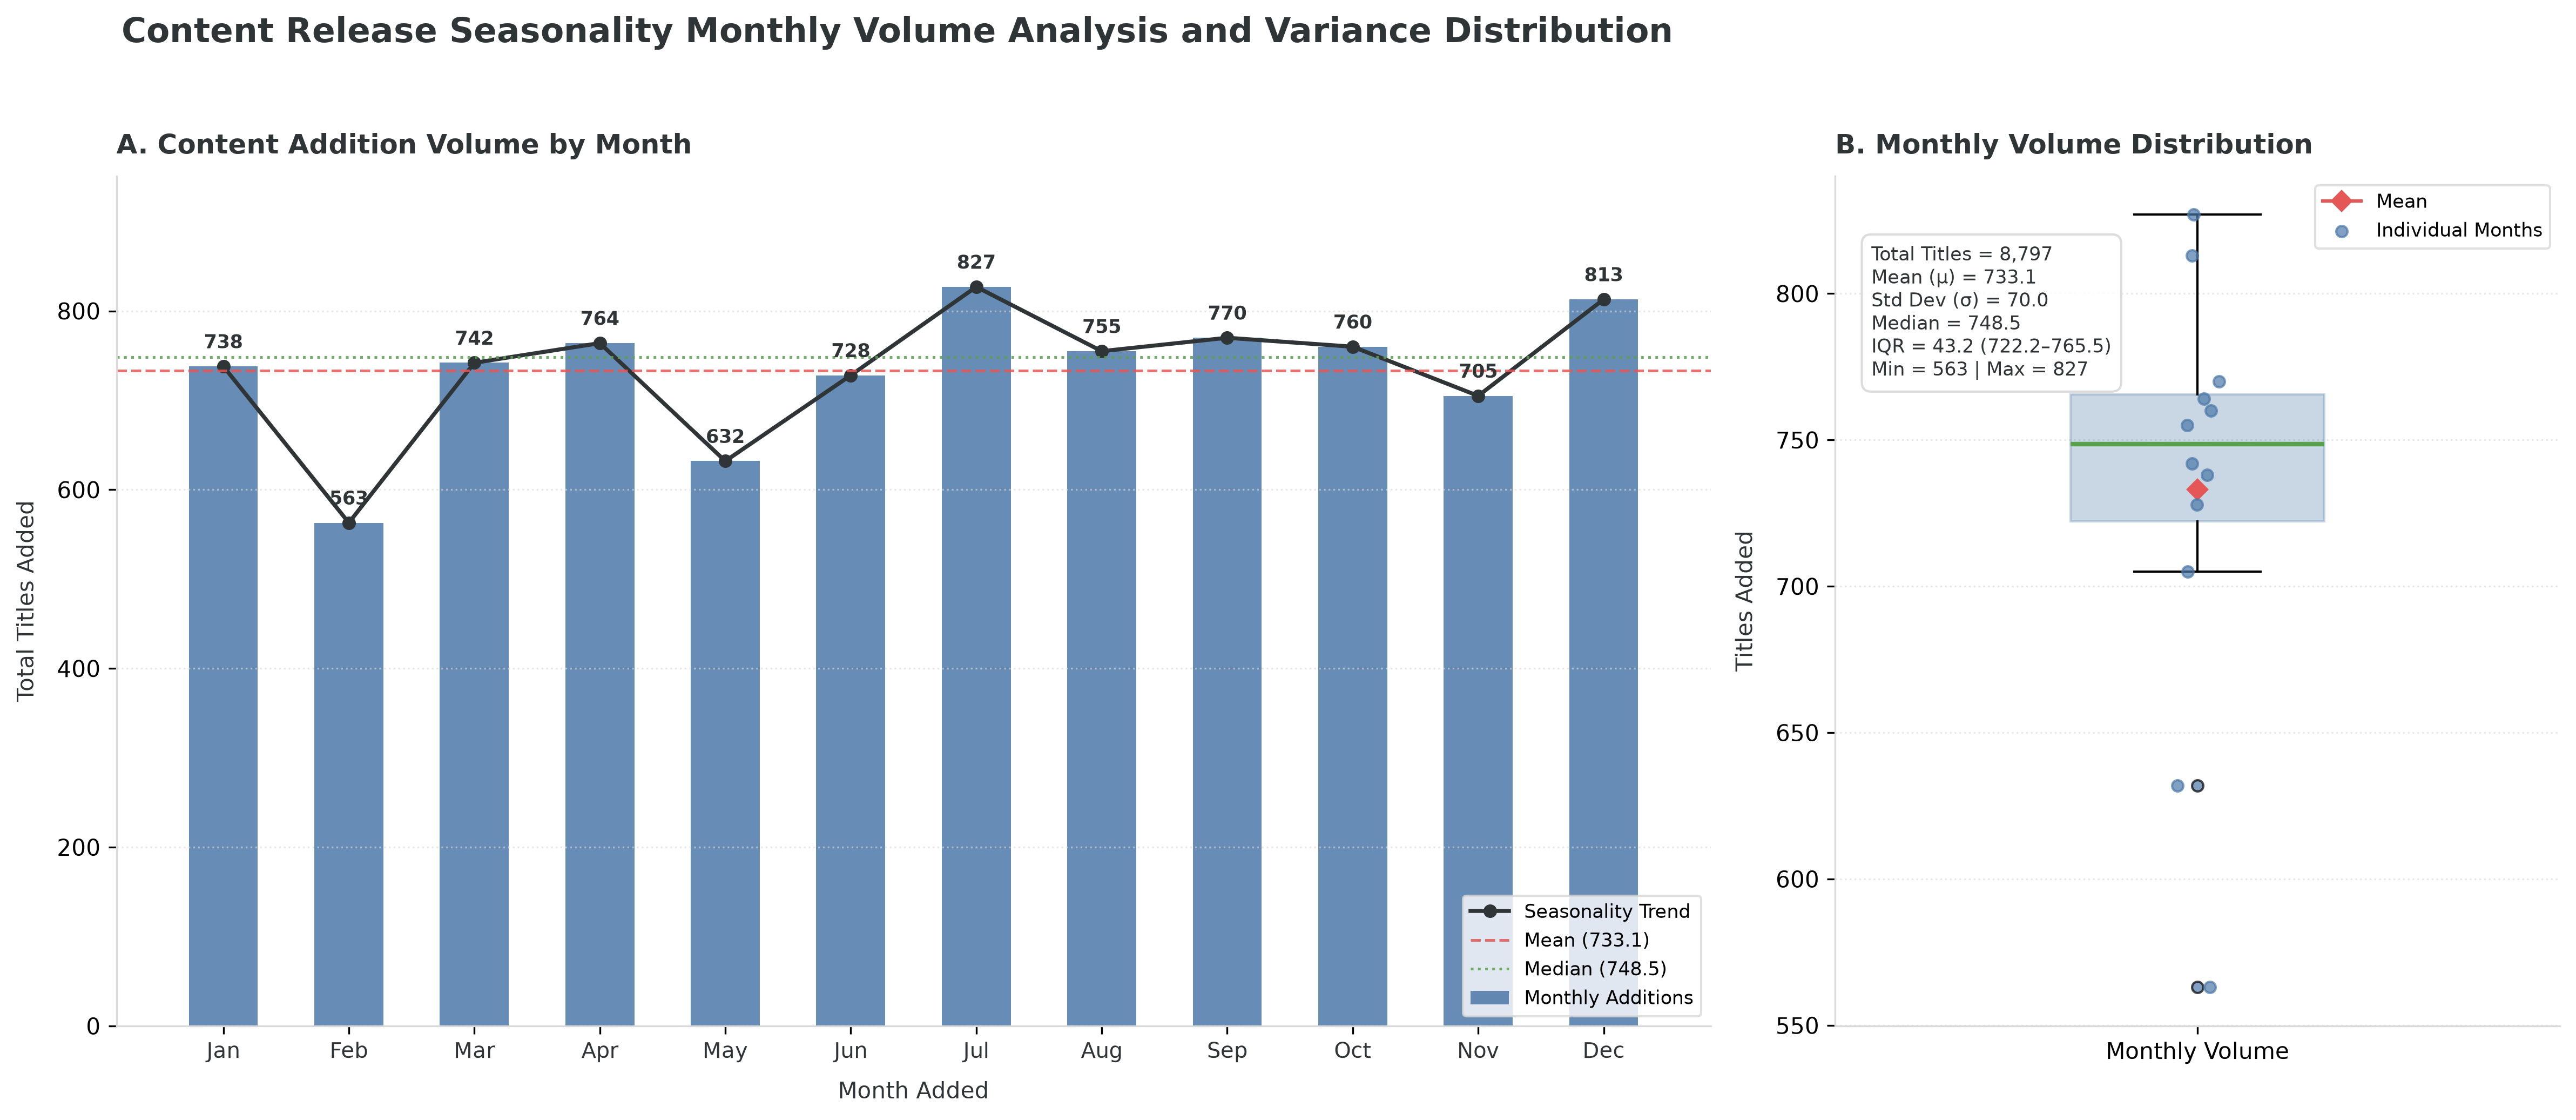

In [308]:
months = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]
df_plot = content_seasonality.copy()
df_plot.index = months

if df_plot["titles"].isna().any():
    df_plot = content_seasonality.copy()

titles_data = df_plot["titles"].values
month_labels = [m[:3] for m in df_plot.index]

mean_val = np.mean(titles_data)
median_val = np.median(titles_data)
std_val = np.std(titles_data)
q25, q75 = np.percentile(titles_data, [25, 75])
iqr_val = q75 - q25
min_val, max_val = np.min(titles_data), np.max(titles_data)
total_n = np.sum(titles_data)

fig, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 7),
    dpi=300,
    facecolor="#FFFFFF",
    gridspec_kw={"width_ratios": [2.2, 1]},
)

ax1.set_facecolor("#FFFFFF")
ax2.set_facecolor("#FFFFFF")

x_pos = np.arange(len(month_labels))

bars = ax1.bar(
    x_pos,
    titles_data,
    color="#4C78A8",
    width=0.55,
    alpha=0.85,
    edgecolor="none",
    label="Monthly Additions",
)

ax1.plot(
    x_pos,
    titles_data,
    color="#2F3437",
    linewidth=1.8,
    marker="o",
    markersize=5,
    label="Seasonality Trend",
)

ax1.axhline(
    mean_val,
    color="#E45756",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    label=f"Mean ({mean_val:.1f})",
)
ax1.axhline(
    median_val,
    color="#59A14F",
    linestyle=":",
    linewidth=1.2,
    alpha=0.85,
    label=f"Median ({median_val:.1f})",
)

for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f"{int(height):,}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8.5,
        color="#2F3437",
        fontweight="semibold",
    )

ax1.set_xticks(x_pos)
ax1.set_xticklabels(month_labels, fontsize=9.5, color="#2F3437")
ax1.set_xlabel("Month Added", fontsize=10, color="#2F3437", labelpad=8)
ax1.set_ylabel("Total Titles Added", fontsize=10, color="#2F3437", labelpad=8)
ax1.set_title(
    "A. Content Addition Volume by Month",
    fontsize=12,
    fontweight="bold",
    pad=10,
    loc="left",
    color="#2F3437",
)
ax1.set_ylim(0, max_val * 1.15)
ax1.grid(True, axis="y", linestyle=":", alpha=0.6, color="#D9D9D9")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color("#D9D9D9")
ax1.spines["bottom"].set_color("#D9D9D9")
ax1.legend(
    loc="lower right",
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="#D9D9D9",
    fontsize=8.5,
)

bplot = ax2.boxplot(
    [titles_data],
    patch_artist=True,
    tick_labels=["Monthly Volume"],
    widths=0.35,
    medianprops={"color": "#59A14F", "linewidth": 2},
    flierprops={
        "marker": "o",
        "markersize": 5,
        "alpha": 0.7,
        "markerfacecolor": "#4C78A8",
    },
)

for patch in bplot["boxes"]:
    patch.set_facecolor("#4C78A8")
    patch.set_alpha(0.3)
    patch.set_edgecolor("#4C78A8")

ax2.plot(
    1,
    mean_val,
    marker="D",
    color="#E45756",
    markersize=6,
    label="Mean",
)

jitter = np.random.normal(1, 0.03, size=len(titles_data))
ax2.scatter(
    jitter,
    titles_data,
    color="#4C78A8",
    alpha=0.7,
    s=25,
    zorder=3,
    label="Individual Months",
)

ax2.set_title(
    "B. Monthly Volume Distribution",
    fontsize=12,
    fontweight="bold",
    pad=10,
    loc="left",
    color="#2F3437",
)
ax2.set_ylabel("Titles Added", fontsize=10, color="#2F3437", labelpad=8)
ax2.grid(True, axis="y", linestyle=":", alpha=0.6, color="#D9D9D9")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color("#D9D9D9")
ax2.spines["bottom"].set_color("#D9D9D9")

stats_text = (
    f"Total Titles = {total_n:,}\n"
    f"Mean (μ) = {mean_val:.1f}\n"
    f"Std Dev (σ) = {std_val:.1f}\n"
    f"Median = {median_val:.1f}\n"
    f"IQR = {iqr_val:.1f} ({q25:.1f}–{q75:.1f})\n"
    f"Min = {min_val:,} | Max = {max_val:,}"
)
ax2.text(
    0.05,
    0.92,
    stats_text,
    transform=ax2.transAxes,
    fontsize=8.5,
    verticalalignment="top",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "#FFFFFF",
        "edgecolor": "#D9D9D9",
        "alpha": 0.9,
    },
    color="#2F3437",
)

ax2.legend(
    loc="upper right",
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="#D9D9D9",
    fontsize=8.5,
)

title_text = "Content Release Seasonality Monthly Volume Analysis and Variance Distribution"
fig.suptitle(
    title_text,
    fontsize=15,
    fontweight="bold",
    y=0.98,
    x=0.05,
    ha="left",
    color="#2F3437",
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path, dpi=800, bbox_inches="tight", facecolor=fig.get_facecolor()
)

### 14. International Expansion Tracking

In [309]:
international_expansion = df[["show_id", "type", "release_year", "country"]]

international_expansion["release_year"] = international_expansion[
    "release_year"
].dt.year

indices_to_drop = international_expansion[
    international_expansion["country"] == "unrecorded"
].index

international_expansion["country"] = international_expansion["country"].drop(
    indices_to_drop
)

international_expansion = international_expansion.dropna()

In [310]:
international_expansion["country"] = international_expansion[
    "country"
].str.split(", ")

international_expansion = international_expansion.explode(
    column="country", ignore_index=True
)

In [311]:
usa_ids = international_expansion[
    international_expansion["country"] == "United States"
]["show_id"]

international_expansion = international_expansion[
    ~international_expansion["show_id"].isin(usa_ids)
]

In [312]:
international_expansion.head()

,show_id,type,release_year,country
1,s2,TV Show,2021,South Africa
2,s5,TV Show,2021,India
9,s9,TV Show,2021,United Kingdom
11,s13,Movie,2021,Germany
12,s13,Movie,2021,Czech Republic


In [313]:
international_expansion = international_expansion.groupby(
    by=["release_year", "country"]
).agg(
    tv_shows=(
        "type",
        lambda show_type: (show_type == "TV Show").count(),
    ),
    movies=(
        "type",
        lambda show_type: (show_type == "Movie").count(),
    ),
)

In [314]:
international_expansion = international_expansion.reset_index()

In [315]:
international_expansion.head()

,release_year,country,tv_shows,movies
0,1954,Egypt,1,1
1,1955,France,1,1
2,1955,Italy,2,2
3,1956,Egypt,1,1
4,1958,Egypt,1,1


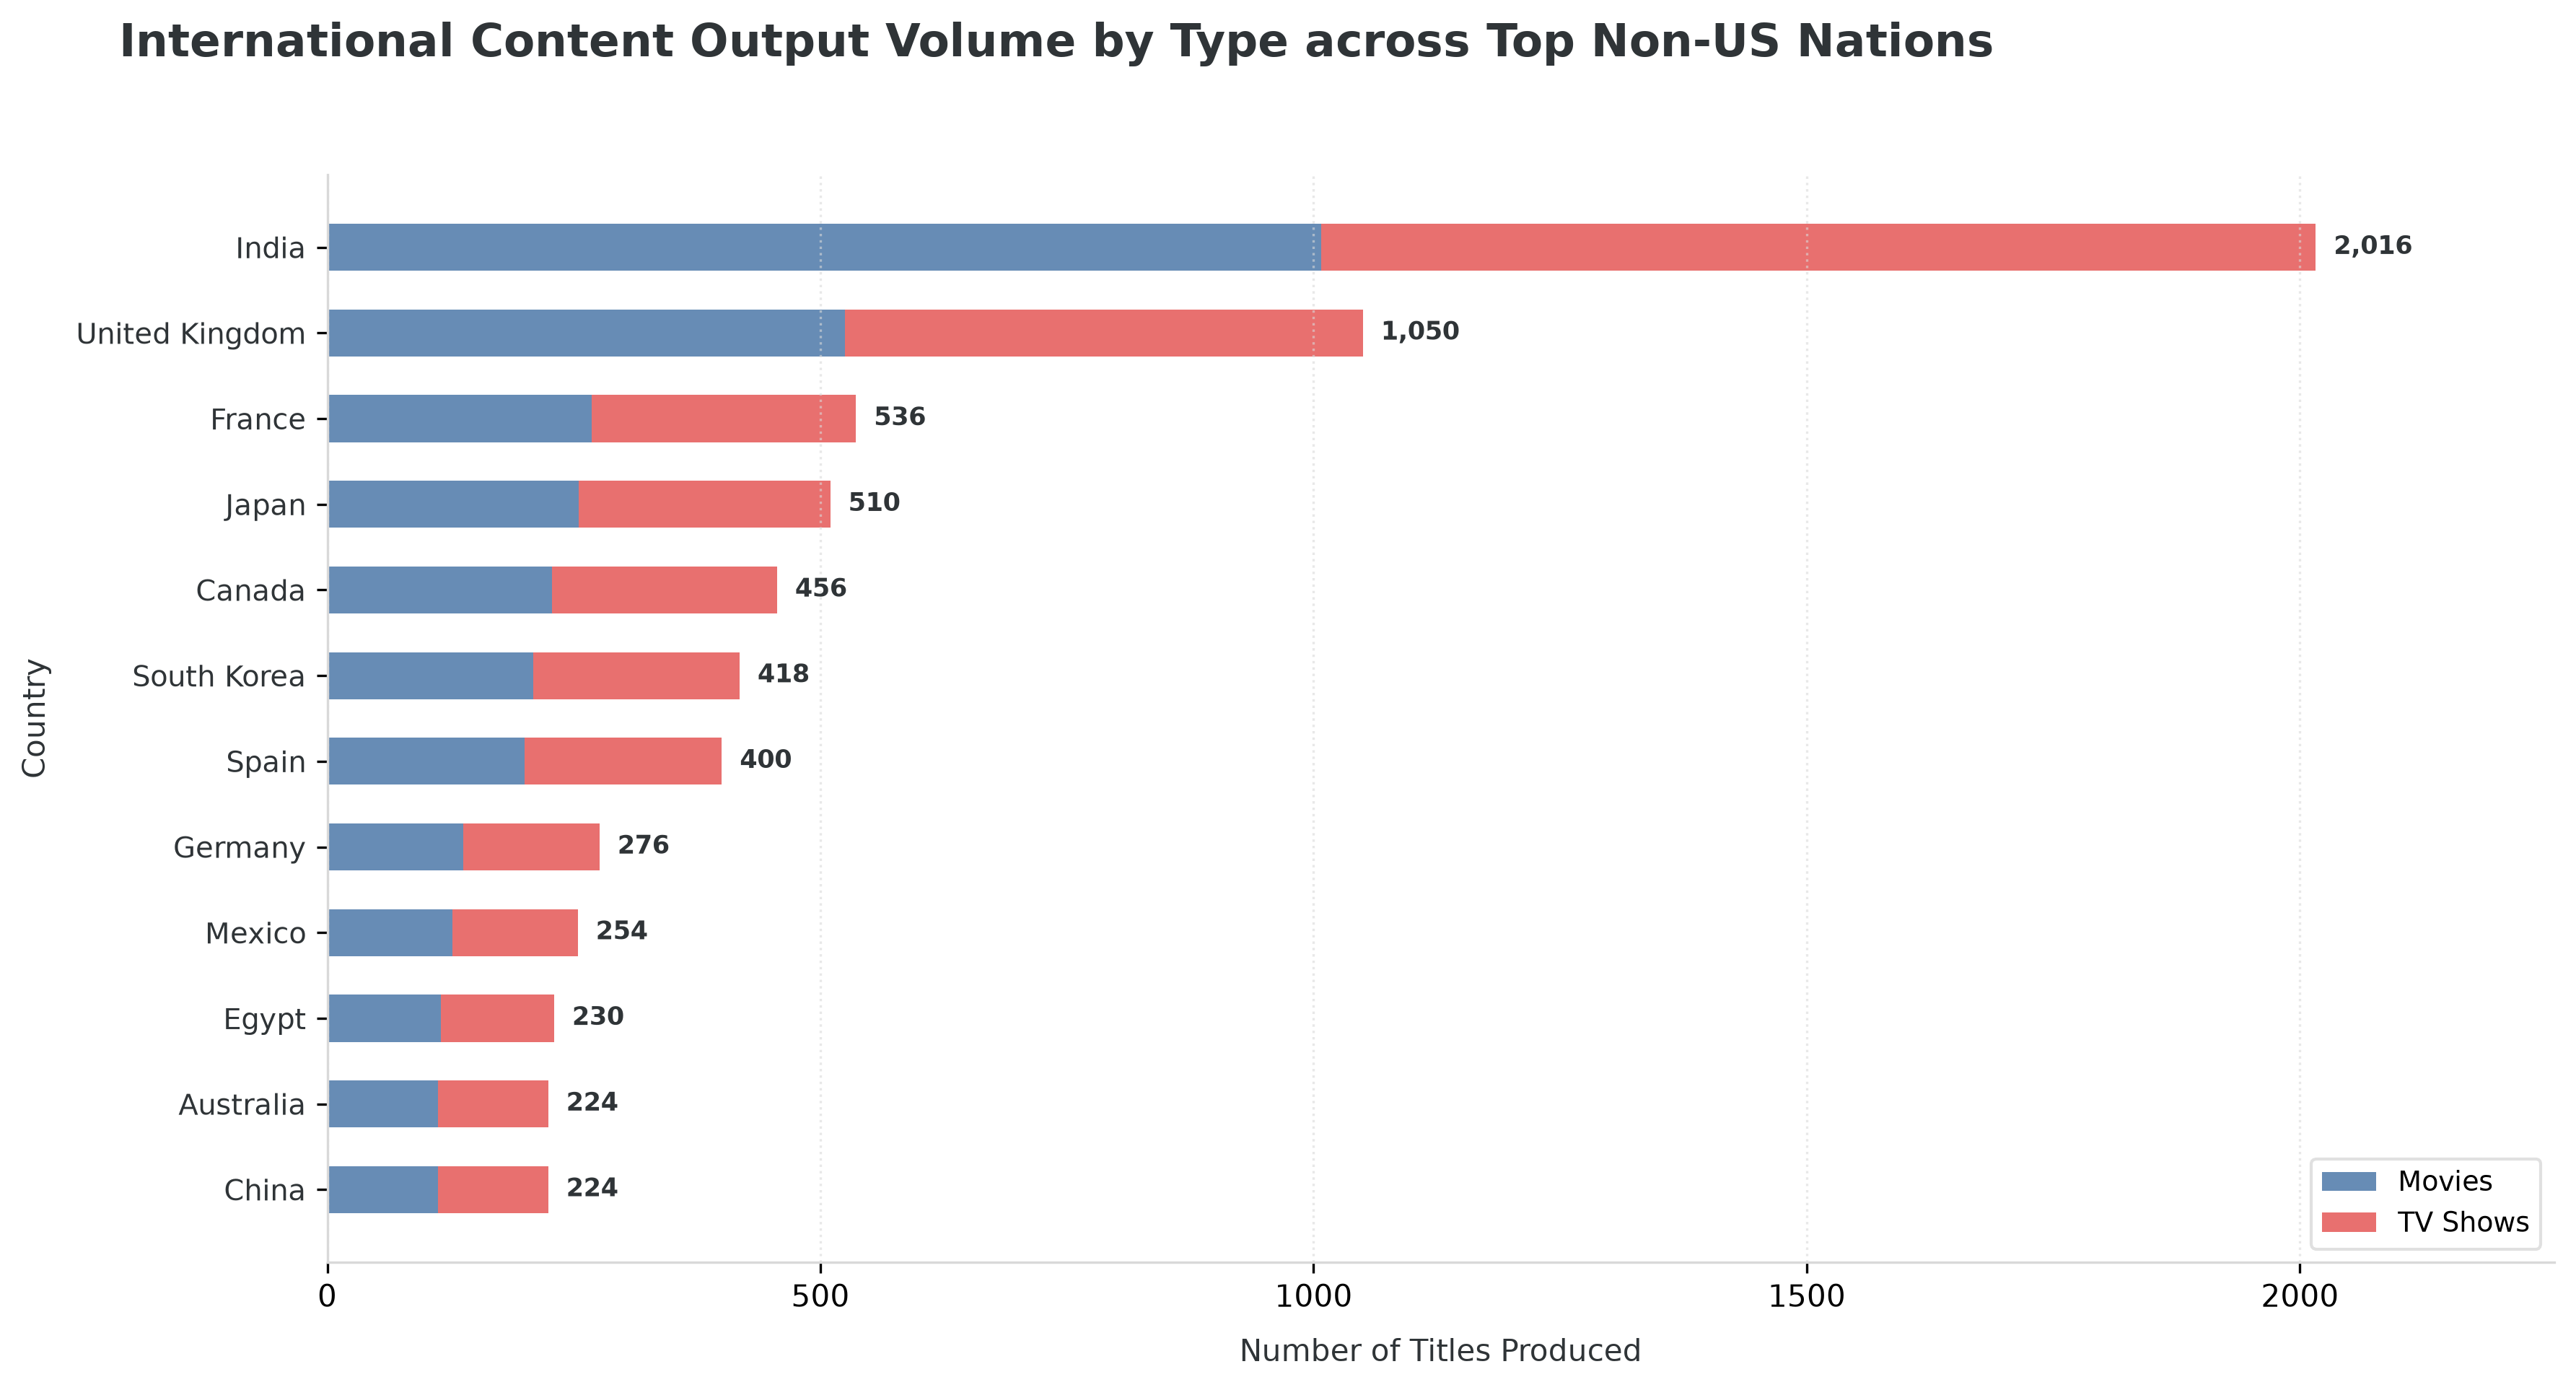

In [316]:
country_totals = (
    international_expansion.groupby("country")[["movies", "tv_shows"]]
    .sum()
    .assign(total=lambda df: df["movies"] + df["tv_shows"])
    .sort_values(by="total", ascending=False)
)

top_12 = country_totals.head(12).sort_values(by="total", ascending=True)

countries = top_12.index.tolist()
movies_val = top_12["movies"].values
tv_val = top_12["tv_shows"].values
total_val = top_12["total"].values

fig, ax1 = plt.subplots(
    figsize=(12, 6.5),
    dpi=300,
    facecolor="#FFFFFF",
)

ax1.set_facecolor("#FFFFFF")

y_pos = np.arange(len(countries))

bars_movies = ax1.barh(
    y_pos,
    movies_val,
    color="#4C78A8",
    height=0.55,
    alpha=0.85,
    label="Movies",
)

bars_tv = ax1.barh(
    y_pos,
    tv_val,
    left=movies_val,
    color="#E45756",
    height=0.55,
    alpha=0.85,
    label="TV Shows",
)

for i, (m, t, tot) in enumerate(zip(movies_val, tv_val, total_val)):
    ax1.annotate(
        f"{tot:,}",
        xy=(tot, y_pos[i]),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8.5,
        color="#2F3437",
        fontweight="semibold",
    )

ax1.set_yticks(y_pos)
ax1.set_yticklabels(countries, fontsize=9.5, color="#2F3437")
ax1.set_xlabel(
    "Number of Titles Produced", fontsize=10, color="#2F3437", labelpad=8
)
ax1.set_ylabel("Country", fontsize=10, color="#2F3437", labelpad=8)
ax1.set_xlim(0, max(total_val) * 1.12)
ax1.grid(True, axis="x", linestyle=":", alpha=0.6, color="#D9D9D9")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color("#D9D9D9")
ax1.spines["bottom"].set_color("#D9D9D9")
ax1.legend(
    loc="lower right",
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="#D9D9D9",
    fontsize=9,
)

title_text = (
    "International Content Output Volume by Type across Top Non-US Nations"
)
fig.suptitle(
    title_text,
    fontsize=15,
    fontweight="bold",
    y=0.98,
    x=0.05,
    ha="left",
    color="#2F3437",
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path, dpi=800, bbox_inches="tight", facecolor=fig.get_facecolor()
)

### 15. Movie Duration Evolution

In [317]:
duration_evolution = df[["show_id", "type", "duration", "release_year"]]
duration_evolution = duration_evolution[duration_evolution["type"] == "Movie"]

duration_evolution["release_year"] = duration_evolution["release_year"].dt.year
duration_evolution["duration"] = (
    duration_evolution["duration"]
    .str.strip()
    .str.split()
    .str.slice(start=0, stop=1)
    .str.join(sep="")
)

In [318]:
duration_evolution.head()

,show_id,type,duration,release_year
0,s1,Movie,90,2020
6,s7,Movie,91,2021
7,s8,Movie,125,1993
9,s10,Movie,104,2021
12,s13,Movie,127,2021


In [319]:
indeces_to_drop = duration_evolution[
    duration_evolution["duration"] == "unrecorded"
].index

duration_evolution["duration"] = duration_evolution["duration"].drop(
    indeces_to_drop
)

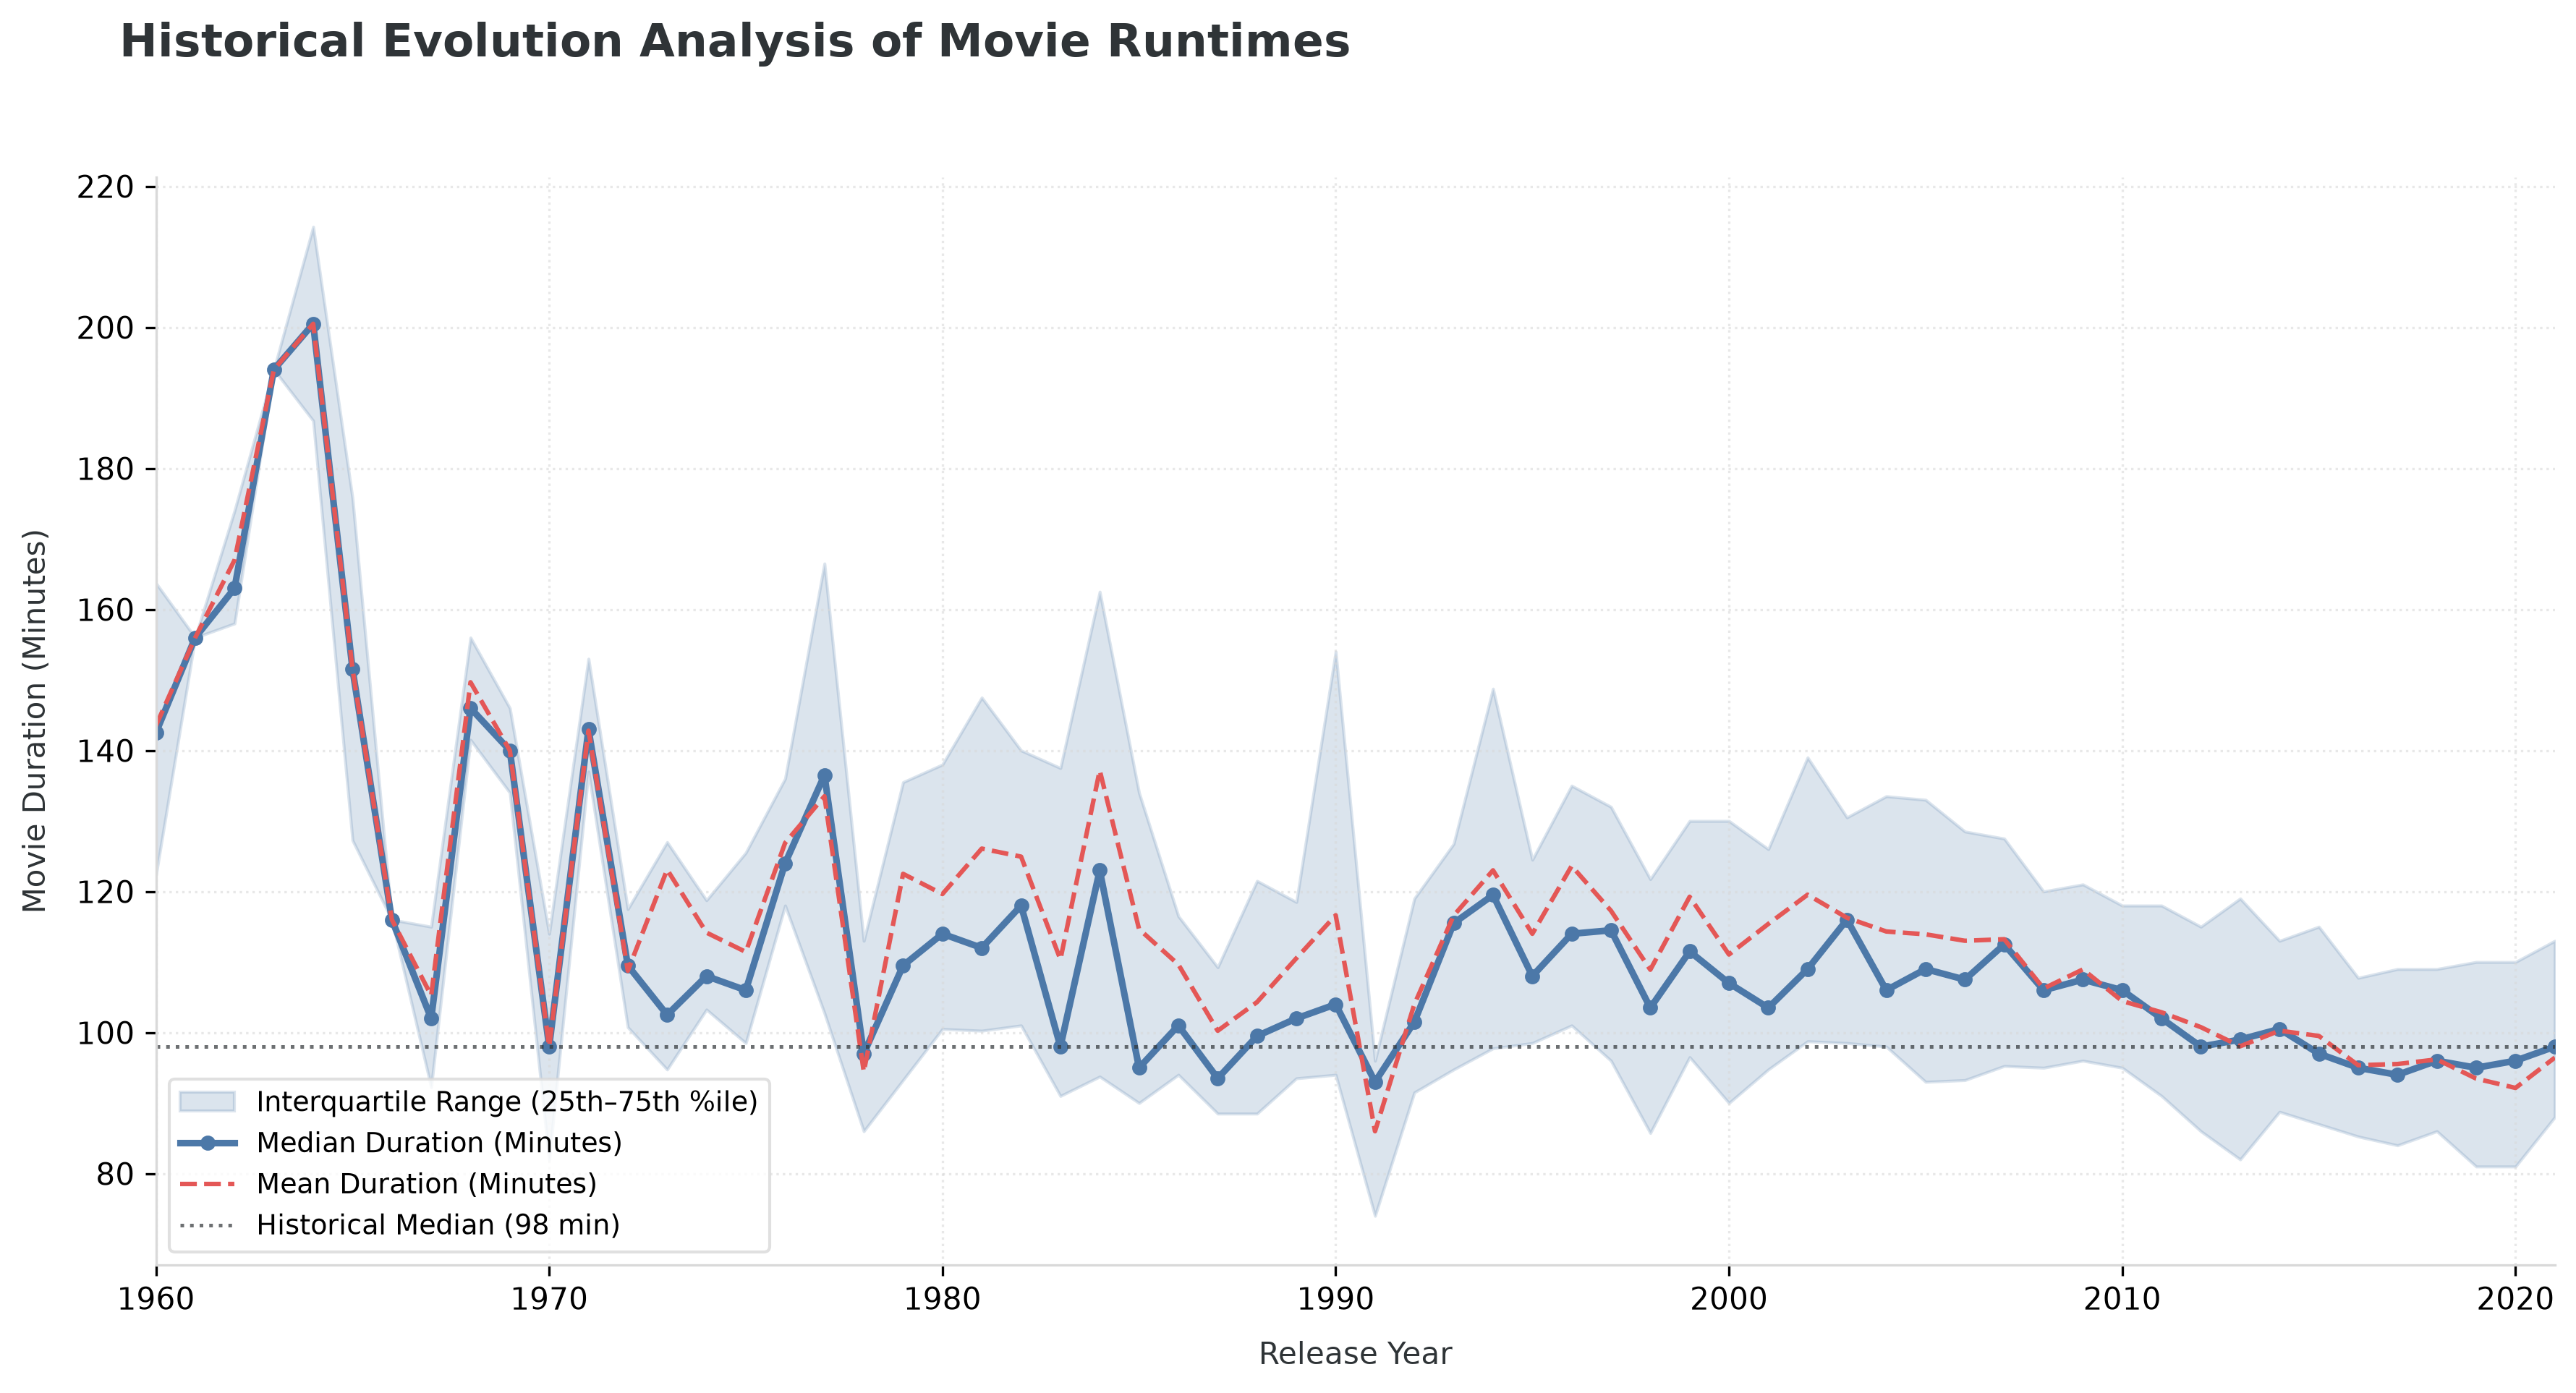

In [320]:
df_movies = duration_evolution.dropna(
    subset=["duration", "release_year"]
).copy()
df_movies["duration"] = df_movies["duration"].astype(float)
df_movies["release_year"] = df_movies["release_year"].astype(int)

yearly_stats = (
    df_movies.groupby("release_year")["duration"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        q25=lambda x: np.percentile(x, 25),
        q75=lambda x: np.percentile(x, 75),
    )
    .reset_index()
)

yearly_stats = yearly_stats[yearly_stats["release_year"] >= 1960]

all_durations = df_movies["duration"].values
overall_median = np.median(all_durations)

fig, ax1 = plt.subplots(
    figsize=(12, 6.5),
    dpi=300,
    facecolor="#FFFFFF",
)

ax1.set_facecolor("#FFFFFF")

ax1.fill_between(
    yearly_stats["release_year"],
    yearly_stats["q25"],
    yearly_stats["q75"],
    color="#4C78A8",
    alpha=0.2,
    label="Interquartile Range (25th–75th %ile)",
)

ax1.plot(
    yearly_stats["release_year"],
    yearly_stats["median"],
    color="#4C78A8",
    linewidth=2.2,
    marker="o",
    markersize=4,
    label="Median Duration (Minutes)",
)

ax1.plot(
    yearly_stats["release_year"],
    yearly_stats["mean"],
    color="#E45756",
    linewidth=1.5,
    linestyle="--",
    label="Mean Duration (Minutes)",
)

ax1.axhline(
    overall_median,
    color="#2F3437",
    linestyle=":",
    linewidth=1.2,
    alpha=0.7,
    label=f"Historical Median ({overall_median:.0f} min)",
)

ax1.set_xlabel("Release Year", fontsize=10, color="#2F3437", labelpad=8)
ax1.set_ylabel(
    "Movie Duration (Minutes)", fontsize=10, color="#2F3437", labelpad=8
)
ax1.set_xlim(
    yearly_stats["release_year"].min(), yearly_stats["release_year"].max()
)
ax1.grid(True, axis="both", linestyle=":", alpha=0.6, color="#D9D9D9")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color("#D9D9D9")
ax1.spines["bottom"].set_color("#D9D9D9")
ax1.legend(
    loc="lower left",
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="#D9D9D9",
    fontsize=9,
)

title_text = "Historical Evolution Analysis of Movie Runtimes"
fig.suptitle(
    title_text,
    fontsize=15,
    fontweight="bold",
    y=0.98,
    x=0.05,
    ha="left",
    color="#2F3437",
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

output_dir = os.path.join("..", "gallery")
os.makedirs(output_dir, exist_ok=True)

filename = (
    re.sub(r"[^\w\s-]", "", title_text).strip().replace(" ", "_") + ".png"
)
file_path = os.path.join(output_dir, filename)

plt.savefig(
    file_path, dpi=800, bbox_inches="tight", facecolor=fig.get_facecolor()
)
